# Twitch local pricing experiment

A simulated pricing experiment run end to end, built to practice the design decisions rather than the arithmetic.

Nothing here is Twitch internal and the data is synthetic. The product structure it is calibrated against is public: local pricing set by viewer country, the 50/50 and 70/30 subscription splits, and subscribers not seeing ads on the channel they subscribe to.

## How to read this

Every design section has the same shape.

The question comes first, before the answer, so you can commit to a position and find out where you land.

Then the sixty second answer, which is what I would say out loud if someone asked me in a meeting. It is deliberately the simple version.

Then the reasoning, which is what I would say only if pushed.

Then a short note on what the question is testing, since interview questions about experiment design usually probe something narrower than they appear to.

The simple answer comes first every time, on purpose. Reaching for the sophisticated method before establishing the defensible one is how you lose a room.

The data generating process has a set of true parameters. They are written into the code in section 5 but never discussed until section 19, and every analysis before that point is done as if they were unknown. At the end we check whether the machinery recovered them. That check is the part a real experiment can never give you, and it is the reason to build a simulated one.

## 1. The business question

Twitch sets subscription prices by viewer country. In this market Tier 1 costs R$9.90 a month. Paid subscriptions have been flat for three quarters while viewing hours have grown.

Commerce wants to cut Tier 1 to R$7.90, a 20.2% reduction, on the theory that price is what holds back conversion.

### What the question is not

Whether a lower price sells more subscriptions. It does. That is not in dispute and does not need an experiment.

### What it is

A price cut is a discount to everyone, including the people who would have paid R$9.90 without complaint. The question is whether the subscriptions we gain cover the money we give up on the ones we were going to win anyway.

Every decision below exists to answer that sentence.

### The decision

Ship the cut, hold at R$9.90, or come back with a different price or a targeted variant. Three outcomes, committed to before any data arrives.

### Objective

Net platform revenue. Twitch's share after the revenue split, plus Bits margin, plus advertising. Not gross subscription revenue, and not subscription count.

The split matters because it varies. Standard channels are 50/50 and Partner Plus channels are 70/30, so the same price cut is worth different amounts depending on which channels it lands in. Gross revenue hides that.

### The scope boundary

This experiment measures the price effect on new subscriber acquisition. It does not measure what happens when the existing base gets repriced, because we are not repricing them during the test.

I got this wrong on the first pass and the correction is worth keeping. My original note said no experiment could measure the existing base effect. False. You can randomize existing subscribers into keep paying R$9.90 against now pay R$7.90 and read retention, and charging someone less needs nobody's consent. It is a second experiment with a different unit and a much longer horizon, since churn takes months to read.

The correct statement is narrower. This experiment alone does not support a ship decision, because the ship applies to two populations and we are testing one.

The untested half gets a threshold analysis in section 18. Assume a retention response, compute the full profit and loss, then solve for how much retention would have to improve to flip the decision. If the answer is plausible, the second experiment has to come first. If it is not, we can decide without it.

Turning "we do not know" into "here is what we would need to know, and whether it is worth finding out" beats both shipping blind and refusing to answer.

### An asymmetry worth noticing

The two populations want opposite randomization units. New subscribers see the price on a public page inside a public chat, so price has to be uniform per channel. Existing subscribers see their renewal price privately and nobody announces what they pay, so subscriber level randomization is fine there.

Same product, same price change, opposite designs, because the leakage structure differs.

## 2. The unit of randomization

> **Before reading on.** Four candidates: viewer, viewer by channel, channel, geography. Rank them, and for each rejection name the specific thing that kills it. Less power is not a kill.

### Sixty second answer

Channel level. Twitch has gift subscriptions, so at viewer level one user can buy a subscription on another user's behalf, which moves treatment between units through an ordinary product feature. That is interference, not a nuisance. I would cluster at the channel, pay for it in variance, and get the power back with stratification and CUPED. I would also flag that channel level randomization leaves cross channel substitution in place, since viewers watch many channels.

### Why the alternatives fail

**Viewer level.** The most powerful option, and it fails on interference.

Gifting is a treatment transfer mechanism built into the product. A control viewer who wants a subscription asks a treated friend to gift one. Mass gifters buy a hundred subscriptions at once, so a single treated unit can hand treated prices to a hundred control units. You can write a rule saying the payer's price applies, so this is not logically incoherent. The problem is the volume of leakage, not the definition.

There is also a fairness question. Price already varies by country and viewers accept that, because geography is a story people understand. Two viewers in the same market paying different prices for the same thing has no story attached.

**Viewer by channel.** Fails on estimand, which is the more interesting failure.

The treatment you measure has to be the treatment you would ship. Ship the cut and everyone pays R$7.90, so no dispersion exists anywhere. A design that manufactures dispersion measures the reaction to dispersion, meaning anchoring and shopping around, not the reaction to a price level. You get a clean, well powered, significant estimate of the wrong quantity, which is worse than a noisy estimate of the right one.

**Geography.** Not available inside one market. Local pricing is a country level surface, so sub country randomization means building price granularity that does not exist. Across markets you get a handful of countries that differ in everything.

Geography's role here is the rollout mechanism, not a randomization alternative. Once the channel test produces an effect size, a staged country by country launch read with synthetic control is the confirmatory step.

**Channel.** What survives, and what it does not fix.

Channel randomization makes price uniform inside any one chat, which lowers the salience of the dispersion. It does not remove the fairness question, it hides it.

Two costs.

*Clustering.* Viewers sit inside channels and correlate within them, and channel sizes follow a power law, so the design effect is severe. That is section 7's whole problem.

*Cross cluster interference, which channel randomization does not solve.* Viewers watch many channels. If subscription budgets are roughly fixed, a treated channel takes subscriptions from control channels, inflating treatment and deflating control at once. Section 17 measures how much.

### The principle

> The randomization unit is set by the leakage structure of the treatment. You pay for that choice in variance.

Not the reverse. Choosing the unit by power and adding interference caveats afterward inverts the causal logic, and it shows.

### On disclosure

Whether to tell streamers a pricing test is running looks operational. It is a treatment definition question, which makes it a SUTVA question.

SUTVA has two halves. Everyone remembers no interference. The other half is consistency, meaning one version of the treatment.

If treated streamers know and promote the discount, the treatment becomes price cut plus promotional push, varying streamer to streamer. That is multiple versions, which breaks consistency. And since only treated streamers would know, awareness becomes a post randomization variable correlated with assignment, which is the one sided non compliance confound.

**Decision.** Tell every participating streamer that a pricing test is running. Tell nobody their arm. You cannot blind viewers since they see the price, but you can blind streamers, and symmetric awareness makes any awareness effect a common shock that differences out.

The cost, which should be said without being asked. Symmetric disclosure adds a uniform awareness effect present in the experiment and absent at launch. It pushes both arms the same direction so the difference survives, unless awareness interacts with price, which it plausibly does. Handled by dropping the burn in week and checking whether the effect decays.

### What this question is testing

Whether SUTVA comes before power in your reasoning, and whether you can tell the difference between something being harder to estimate and something being a different estimand.

## 3. Where a network and Bayesian background changes the answer

Two things I know well that most candidates for a pricing role do not: network dependence, and Bayesian hierarchical modeling. They turn out to be the same tool applied at two points in this design, so they belong in one section.

The honest version of the claim is more useful than the flattering one, so the limits are written in.

### 3.1 The interference problem is a network problem

Channel randomization leaves cross channel substitution alone. Viewers watch many channels, budgets are roughly fixed, and a cheaper channel pulls subscriptions from its neighbours.

The literature calls this graph cluster randomization. Partition the graph so most substitution happens inside clusters, then randomize whole clusters (Ugander, Karrer, Backstrom and Kleinberg, KDD 2013).

Twitch does not partition cleanly. A viewer watches three Valorant streamers, a variety streamer, and a friend's twelve viewer channel. Five options, roughly in the order I would try them.

**Bound it instead of fixing it.** Compute from pre period data what share of control viewers' watch time lands in treated channels. If it comes back small, contamination is small and the bias can be bounded on paper. Cheapest option, usually enough, and the one to lead with. Section 17 does exactly this. Escalate only if the number is ugly.

**Exposure mapping instead of partitioning.** Randomize channels independently, then give each viewer a continuous exposure equal to their share of watch time in treated channels, and estimate a dose response. Overlap stops being a problem to solve.

One trap. Exposure computed from concurrent viewing is endogenous, since treatment can change where people watch. Compute it from the pre period, which makes it a function of randomization and pre treatment covariates only. Aronow and Samii (2017) covers estimation under exposure mappings.

**Hard partition, and publish the residual.** Louvain or METIS on the channel co viewing graph, minimize the edge cut, randomize communities, then report the cross boundary attention that remains as the leakage budget.

**Restricted exposure.** Keep only viewers with most of their watching inside their own cluster. Buys cleanliness with sample size, and introduces a selection problem that has to be named out loud: heavy multi channel viewers get dropped, and they are disproportionately where the revenue comes from.

**Two stage saturation.** Randomize markets to treated fractions of 25, 50 and 75 percent, then randomize channels inside them. Estimates spillover directly and extrapolates to full saturation, which is the launch state. The only design that estimates what a launch would do. You usually cannot afford it, since it needs many top level units (Hudgens and Halloran 2008; Baird, Bohren, McIntosh and Ozler 2018).

### 3.2 Does clustering communities cost too much power

Partly. Merging channels into communities cuts the number of independent units and raises mean cluster size, and both hurt. But the intraclass correlation falls at the same time, which offsets some of it.

Write the outcome with three levels:

$$y_{ijk} = \mu + a_k(\text{community}) + b_{jk}(\text{channel}) + e_{ijk}(\text{viewer})$$

Two viewers in the same channel correlate at $(\sigma^2_a + \sigma^2_b)/\sigma^2_{\text{total}}$. Two viewers in the same community but different channels correlate at $\sigma^2_a/\sigma^2_{\text{total}}$, which is strictly smaller.

Pushing that through the design effect approximation, community randomization loses when

$$C > 1 + \sigma^2_b/\sigma^2_a$$

where $C$ is channels per community. Heterogeneous communities let you pool many channels before the power loss bites. Tight, homogeneous communities hurt at $C = 3$.

Treat that as a rough guide, not a result. It assumes equal cluster sizes, which is badly wrong under a power law. The number worth trusting comes out of the simulator.

The framing matters more than the formula.

> Interference is bias. Clustering is variance. Pick the design that minimizes mean squared error for the decision in front of you.

Most people treat interference as a yes or no question about whether SUTVA holds. Neither design dominates. Which one wins depends on how large the substitution is, and that is measurable rather than assumable.

### 3.3 Four things the network background buys

**Community detection has a resolution limit, and it bites here.** Modularity maximization cannot resolve communities below roughly $\sqrt{2m}$ edges (Fortunato and Barthelemy, 2007). Small channels get absorbed into large communities, and under a power law that is most of the channels. Naive Louvain produces close to the wrong clustering for this problem.

**Heavy tailed degree wrecks Horvitz Thompson variance.** Under graph cluster randomization, a unit's exposure probability depends on how many clusters its neighbourhood spans. A high degree viewer touching many clusters needs all of them treated to count as exposed, so the probability gets tiny and the inverse probability weight explodes. With power law degree, a meaningful share of units sit in that tail. This is the failure mode that kills naive network experiment estimators, and it is not obvious unless you have thought about degree distributions.

**Intraclass correlation is not one number.** Standard practice looks up a scalar ICC and reports one minimum detectable effect. In a nested network setting the correlation between two units depends on the path between them: same channel, same community and different channel, linked through a shared viewer, or unlinked. That is a covariance structure on a graph rather than a single parameter, and it changes the power calculation.

**Simulating dependent data is the check.** Generate from a known truth, run the estimator, see whether it recovers that truth with correct coverage. That is the spine of this notebook and it is the methodology from my dissertation work.

**What I should not claim.** Exponential family random graph models are models of tie formation, not causal inference tools. The transferable skill is comfort with dependent data and with simulation as validation, not the model itself. Running Louvain is standard tooling; the edge is in knowing its failure modes, not the function call. This team likely has people who know this literature.

### 3.4 Where the Bayesian side earns its place

Three places, and one where it gets oversold.

**Heterogeneous treatment effects.** Slicing by channel size, market and viewer tenure produces noisy subgroup estimates. Benjamini Hochberg controls the error rate but does nothing for the point estimates, so you end up knowing which slices to distrust without knowing what to believe. A hierarchical model with partial pooling shrinks each subgroup toward the overall effect by an amount the data chooses, which addresses the winner's curse directly and gives a product manager numbers they can act on. Section 16 does this.

**Small numbers of clusters.** Cluster robust standard errors lean on having many clusters, with a rule of thumb around forty. After weighting by size, the effective count here will sit well under the nominal one. A hierarchical model estimates the between cluster variance with a prior instead of an asymptotic argument.

The caveat belongs in the same breath. With few clusters the prior on that variance component does real work, so you have traded an asymptotic assumption for a prior sensitivity you now have to check. Better trade, not a free one.

**Asymmetric loss, which is the argument that lands with the business.** Price cuts are hard to reverse. Putting a price back up churns customers and generates press in a way that never cutting does not, so the cost of shipping a bad cut is much larger than the cost of missing a good one. Null hypothesis testing has no way to say that. A posterior does. Compute expected loss under each action and take the smallest, and report the probability that revenue clears break even instead of a p value against zero. That is the number the decision needs.

**Where it gets oversold.** Sequential monitoring. The posterior's interpretation does not change with the stopping rule, which is a property worth having. But frequentist operating characteristics do change, and if the organization cares about false positive rates you still have to simulate them. Saying Bayesian methods solve peeking is a common tell that someone half knows the material.

Informative priors from past pricing tests are legitimate and add power, but they are politically awkward, since "you assumed the answer" is easy for a skeptic to say. Pre register the prior and show the sensitivity analysis.

### 3.5 Where the two halves meet

The three level variance decomposition in 3.2 is a hierarchical model. Community, channel, viewer. Estimating the intraclass correlations at each level with their uncertainty is a Bayesian multilevel fit, and since the power calculation depends on those correlations, that uncertainty should carry through into the minimum detectable effect. Standard practice plugs in a point estimate and reports one MDE, which overstates what we know.

> The minimum detectable effect has a confidence interval. Almost nobody reports it.

The partition has the same problem one level up. Louvain returns a single clustering with no uncertainty attached. A degree corrected stochastic block model gives a posterior over partitions instead, which can be propagated into the effect estimate. Degree correction is not optional here. The plain block model groups nodes by degree rather than by community, so under a power law it recovers popularity tiers instead of audiences (Karrer and Newman, 2011).

### 3.6 How to use this in a room

Lead with the standard answer. Cluster robust standard errors on channel level means, plus the leakage bound from 3.1. Then say where you would escalate and why.

Opening with a posterior over partitions from a degree corrected block model reads as someone who will turn a two week project into a six month one. The same content, offered as the escalation path for a specific problem that came back ugly, reads as judgment.

Economists on this team will be strong here, not weak. They frame the same issue as partial against general equilibrium and they are good at it. The differentiation is not in noticing the problem. It is in estimating the dependence structure from data, knowing which estimators break when degree is heavy tailed, and validating any of it by simulation.

## 4. Metrics and the decision rule

> **Before reading on.** You have one primary metric, a handful of secondaries, and some guardrails. What is the difference between a secondary and a guardrail, and why do they get different statistical treatment?

### Sixty second answer

Primary is net platform revenue per eligible viewer. Secondaries explain the primary and never override it. Guardrails are things I need to not break, so they get non inferiority tests against a declared margin rather than a test against zero, because failing to detect harm is not the same as detecting no harm.

### The primary metric

**Net platform revenue per eligible viewer per four weeks.**

Numerator, per viewer:

```
net = take_rate x subscription revenue      (50% standard, 30% Partner Plus)
    + bits margin x Bits revenue
    + ad share x (impressions / 1000) x CPM
```

Denominator: **eligible viewers**, meaning weekly active viewers who were not already subscribed to their primary channel when randomization happened.

That exclusion is the single highest leverage decision in the whole design and it deserves its own paragraph.

### Triggering: the good kind and the trap

Already subscribed viewers cannot respond to a price change on new subscriptions. Leaving them in the denominator adds a large block of constant revenue to both arms, which dilutes the effect without adding information. Taking them out roughly triples the detectable signal.

This is legitimate because **subscription status is fixed before randomization**. It is a pre treatment covariate. The arms stay comparable.

The trap that looks identical and is not: filtering on anything measured *after* randomization. "Only analyze viewers who clicked the subscribe button" is a post treatment filter, and since treatment changes who clicks, the two arms are no longer comparable populations. Same operation, opposite validity, and the only thing separating them is whether the filter variable was determined before or after assignment.

> Pre treatment triggering is free power. Post treatment triggering is selection bias wearing the same clothes.

### Secondaries

New subscriber conversion rate, subscription revenue, Bits revenue, ad revenue, ad impressions per viewer. These decompose the primary and tell us *why* it moved. They are tested as a family with Benjamini Hochberg. They do not get a vote on the decision.

### Guardrails

Watch time per viewer and Bits revenue per viewer. Tested for non inferiority against a declared margin of 2% relative. The null is "harm of at least 2%", and we need to reject it. A large p value on a two sided test against zero proves nothing except that the test was underpowered.

### The decision rule, fixed before any data exists

1. Health checks pass, or the experiment is not read at all.
2. Primary effect on net revenue per eligible viewer, one sided at 5%, must be positive.
3. Both guardrails clear non inferiority at the 2% margin.
4. The measured effect is corrected for cross channel interference (section 17), and the corrected number is what goes into the profit and loss.
5. The full ship profit and loss (section 18) must be positive after adding the existing base repricing term.

All five, or we do not ship. Written down now so that nobody gets to relitigate it after seeing the numbers.

### The elasticity cross check, kept small

Elasticity is not the test. It does three jobs, each of which takes a line.

It sets the required effect size before we look at any variance. For a pure price change, revenue is unchanged exactly when the midpoint own price elasticity equals $-1$:

$$\varepsilon_{\text{mid}} = \frac{\Delta q / \bar q}{\Delta p / \bar p} = \frac{(q_2-q_1)(p_1+p_2)}{(p_2-p_1)(q_1+q_2)} = -1 \quad\text{whenever}\quad p_1q_1 = p_2q_2$$

That is an identity, not a rule of thumb. A 20.2% cut needs 25.3% more units to break even on subscription revenue alone.

It cross checks the revenue result. If the revenue confidence interval excludes zero but the implied elasticity sits above $-1$, the accounting is wrong somewhere, most likely the take rate mix or the ad offset.

And it says what two cells cannot tell you. Two price points give one point on the demand curve, not the curve. The revenue optimal price needs three or four cells, and that is a different, more expensive experiment.

### What this question is testing

Whether you know that a guardrail and a secondary are different objects, and whether you will say out loud that a non significant guardrail is not a passed guardrail.

## 5. The simulated world

Everything below this line is code. The parameters in `TRUTH` are the sealed envelope: they are used to generate data and never referred to again until section 19.

Design of the generator, and why each piece is there:

- **Channels** get a lognormal attractiveness, which produces the power law size distribution that makes the design effect painful. Partner Plus status is correlated with size, so the take rate the business earns depends on which channels convert.
- **Viewers attach to channels preferentially**, so the bipartite viewing graph has realistic overlap. This is what generates cross channel interference later.
- **Subscription is a logit** in log price, with extra price sensitivity for low affinity viewers. That produces heterogeneous elasticity without hand coding it.
- **Pre existing subscribers** are drawn before randomization and grandfathered at the old price, which is what makes the scope boundary in section 1 concrete rather than rhetorical.
- **A cross price term** lets a viewer's conversion at their primary channel fall when their other channels get cheaper. This is the substitution that makes ITT differ from the global effect.
- **All the randomness that is not assignment is drawn once.** Uniforms for the subscription decision, Bits noise, everything. After that, the only thing that varies across replicates is who got treated. That is the potential outcomes framework made literal, and it makes A/A tests and power curves both fast and exact.

In [1]:
import numpy as np, pandas as pd, warnings
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)

# ---- chart styling (categorical slots 1-3 of a CVD-validated palette) ----
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d9d8d4"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.grid": True, "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
def pct(x, _=None): return f"{100*x:.0f}%"

In [2]:
# ============================ SEALED GROUND TRUTH ============================
# Do not read this block again until section 19.
TRUTH = dict(
    beta_logprice = -1.28,   # log-odds of a NEW subscription per log price
    casual_extra  = -0.85,   # extra price sensitivity for low-affinity viewers
    gamma_spill   =  0.22,   # cross-price: cheaper neighbours steal your subs
    bits_shift    = -0.030,  # budget substitution away from Bits
    renewal_shift =  0.004,  # existing-base retention gain (NOT testable here)
)

PRICE_CTRL, PRICE_TRT = 9.90, 7.90
LOGR      = np.log(PRICE_TRT/PRICE_CTRL)
CPM       = 8.0     # gross ad CPM, R$
AD_SHARE  = 0.50    # Twitch share of ad revenue
BITS_MARGIN = 0.30  # Twitch margin on Bits
IMPS_H    = 8.0     # ad impressions per viewer-hour for a non-subscriber
NEW_INT, EXIST_INT = -4.15, -3.95
NON_INF_MARGIN = 0.02   # guardrail non-inferiority margin, relative

In [3]:
def build_world(seed=11, n_channels=5000, n_viewers=3_000_000):
    rng = np.random.default_rng(seed)

    # ---------- channels ----------
    attract = rng.lognormal(0.0, 1.25, n_channels)
    is_pp   = rng.random(n_channels) < 1/(1+np.exp(-(-2.2 + 0.9*np.log(attract))))
    ch = pd.DataFrame(dict(
        channel   = np.arange(n_channels),
        attract   = attract,
        cat       = rng.integers(0, 4, n_channels),
        is_pp     = is_pp,
        take_rate = np.where(is_pp, 0.30, 0.50),
        v         = rng.normal(0, 0.55, n_channels),      # channel quality effect
    ))

    # ---------- bipartite viewer -> channel graph ----------
    m     = np.clip(1 + rng.negative_binomial(1.5, 0.5, n_viewers), 1, 25)
    tot   = int(m.sum())
    e_ch  = rng.choice(n_channels, size=tot, p=attract/attract.sum())
    e_vw  = np.repeat(np.arange(n_viewers), m)
    u_all = rng.normal(0, 1.05, n_viewers)                 # viewer affinity
    e_h   = rng.lognormal(0.35 + 0.30*u_all[e_vw], 0.95, tot)

    order = np.lexsort((-e_h, e_vw))                       # primary channel first
    e_vw, e_ch, e_h = e_vw[order], e_ch[order], e_h[order]
    first = np.ones(tot, bool); first[1:] = e_vw[1:] != e_vw[:-1]
    prim, prim_h = e_ch[first], e_h[first]
    tot_h = np.bincount(e_vw, weights=e_h, minlength=n_viewers)

    v = pd.DataFrame(dict(viewer=np.arange(n_viewers), primary=prim,
                          prim_hours=prim_h, total_hours=tot_h, u=u_all))
    v["focus"]  = v.prim_hours/v.total_hours
    v["casual"] = (v.u.values < np.quantile(u_all, 0.55)).astype(float)
    nv = n_viewers
    v["bits_base"] = (rng.lognormal(0.2+0.35*v.u.values, 1.3, nv)
                      * (rng.random(nv) < 0.10 + 0.05*(v.u.values > 0)))
    v["existing_sub"] = (rng.random(nv) <
        1/(1+np.exp(-(EXIST_INT + 1.15*v.u.values + ch.v.values[prim])))).astype(float)

    # all non-assignment randomness, drawn once
    v["U_new"]      = rng.random(nv)
    v["U_pre"]      = rng.random(nv)
    v["bits_noise"] = rng.lognormal(0, 0.25, nv)

    ch["prim_size"] = np.bincount(prim,  minlength=n_channels)   # viewers whose primary it is
    ch["reach"]     = np.bincount(e_ch,  minlength=n_channels)   # viewers who watch at all
    edges = dict(vw=e_vw, ch=e_ch, h=e_h, first=first)
    return ch, v, edges

In [4]:
class World:
    '''Fast numpy view of the world. net(z) reveals outcomes under assignment z.'''
    def __init__(self, ch, v, edges):
        self.ch, self.v = ch, v
        self.j     = v.primary.values.astype(np.int32)
        self.u     = v.u.values
        self.cas   = v.casual.values
        self.ph    = v.prim_hours.values
        self.oth   = v.total_hours.values - v.prim_hours.values
        self.has_o = self.oth > 1e-9
        self.bits  = v.bits_base.values * v.bits_noise.values
        self.exist = v.existing_sub.values
        self.elig  = self.exist == 0
        self.U, self.Upre = v.U_new.values, v.U_pre.values
        self.take  = ch.take_rate.values[self.j]
        npm = ~edges["first"]                       # non-primary edges only
        self.evw = edges["vw"][npm].astype(np.int32)
        self.ech = edges["ch"][npm].astype(np.int32)
        self.eh  = edges["h"][npm]
        self.n, self.nC = len(v), len(ch)
        self.beta = TRUTH["beta_logprice"] + TRUTH["casual_extra"]*self.cas
        self.base = NEW_INT + self.u + ch.v.values[self.j]

    def exposure(self, z):
        '''share of a viewer's NON-primary watch hours sitting in treated channels'''
        m   = z[self.ech] > 0
        num = np.bincount(self.evw[m], weights=self.eh[m], minlength=self.n)
        return np.where(self.has_o, num/np.maximum(self.oth, 1e-9), 0.0)

    def net(self, z, pre=False, spill=True):
        own   = z[self.j].astype(np.float64)
        ex    = self.exposure(z) if spill else 0.0
        lin   = self.base + self.beta*own*LOGR + TRUTH["gamma_spill"]*ex*LOGR
        p     = 1.0/(1.0+np.exp(-lin))
        U     = self.Upre if pre else self.U
        new   = ((U < p) & self.elig).astype(np.float64)
        price = np.where(own > 0, PRICE_TRT, PRICE_CTRL)
        sub_rev = self.exist*self.take*PRICE_CTRL + new*self.take*price
        any_sub = np.minimum(self.exist + new, 1.0)
        bits    = self.bits*np.where(own > 0, 1+TRUTH["bits_shift"], 1.0)
        imps    = self.ph*IMPS_H*(1-any_sub)
        ad      = AD_SHARE*imps/1000.0*CPM
        return dict(net=sub_rev + BITS_MARGIN*bits + ad, new_sub=new,
                    sub_rev=sub_rev, bits_rev=BITS_MARGIN*bits, ad_rev=ad,
                    imps=imps, hours=self.ph)

In [5]:
import time
t0 = time.time()
ch, v, edges = build_world(seed=11, n_channels=5000, n_viewers=3_000_000)
W  = World(ch, v, edges)
Z0 = np.zeros(W.nC, np.int8)
print(f"built in {time.time()-t0:.1f}s")
print(f"channels {W.nC:,}   viewers {W.n:,}   viewer-channel edges {len(edges['vw']):,}")
print(f"eligible viewers (not already subscribed): {W.elig.sum():,} ({W.elig.mean():.1%})")

built in 8.6s
channels 5,000   viewers 3,000,000   viewer-channel edges 7,500,562
eligible viewers (not already subscribed): 2,882,696 (96.1%)


## 6. Does the simulator look like Twitch

A simulator you have not checked is a random number generator with extra steps. Four things have to look right before any of the analysis means anything.

In [6]:
base = W.net(Z0)                       # everyone at R$9.90
e    = W.elig
s    = ch.prim_size.values
big  = s[s >= 50]

print("CHANNEL SIZE (viewers whose primary this channel is)")
print(f"  median {np.median(s):,.0f}   mean {s.mean():,.0f}   max {s.max():,}")
print(f"  coefficient of variation {s.std()/s.mean():.2f}   (a power law is CV >> 1)")
print(f"  top 1% of channels hold {s[s>=np.quantile(s,0.99)].sum()/s.sum():.1%} of all viewers")
print(f"  channels with >= 50 primary viewers: {(s>=50).sum():,}")

print("\nMONETISATION, per eligible viewer per 4 weeks")
mix = {k: base[k][e].mean() for k in ["sub_rev","bits_rev","ad_rev"]}
tot = base["net"][e].mean()
for k, val in mix.items():
    print(f"  {k:9s} R${val:.4f}   ({val/tot:.0%} of net)")
print(f"  {'net':9s} R${tot:.4f}")
print(f"  new-subscription conversion {base['new_sub'][e].mean():.3%}")
print(f"  already subscribed (excluded) {1-W.elig.mean():.2%} of viewers")
print(f"  Partner Plus channels (Twitch keeps 30%) {ch.is_pp.mean():.1%}")

print("\nOUTCOME SHAPE")
y = base["net"][e]
print(f"  mean R${y.mean():.4f}   sd R${y.std():.4f}   CV {y.std()/y.mean():.2f}")
print(f"  p50 R${np.median(y):.3f}   p99 R${np.quantile(y,0.99):.2f}   max R${y.max():.1f}")
print(f"  share of revenue from the top 1% of viewers: {y[y>=np.quantile(y,0.99)].sum()/y.sum():.1%}")

print("\nVIEWING OVERLAP (this is what creates interference)")
nch = np.bincount(edges['vw'], minlength=W.n)
print(f"  mean channels watched {nch.mean():.2f}   median {np.median(nch):.0f}   p95 {np.quantile(nch,0.95):.0f}")
print(f"  viewers watching more than one channel: {(nch>1).mean():.1%}")
print(f"  mean share of watch time outside the primary channel: {(W.oth/(W.oth+W.ph)).mean():.1%}")

CHANNEL SIZE (viewers whose primary this channel is)
  median 284   mean 600   max 28,992
  coefficient of variation 1.95   (a power law is CV >> 1)
  top 1% of channels hold 14.7% of all viewers
  channels with >= 50 primary viewers: 4,560

MONETISATION, per eligible viewer per 4 weeks
  sub_rev   R$0.1125   (33% of net)
  bits_rev  R$0.1211   (35% of net)
  ad_rev    R$0.1121   (32% of net)
  net       R$0.3457
  new-subscription conversion 2.652%
  already subscribed (excluded) 3.91% of viewers
  Partner Plus channels (Twitch keeps 30%) 15.6%

OUTCOME SHAPE
  mean R$0.3457   sd R$1.1238   CV 3.25
  p50 R$0.093   p99 R$4.95   max R$222.7
  share of revenue from the top 1% of viewers: 36.6%

VIEWING OVERLAP (this is what creates interference)


  mean channels watched 2.50   median 2   p95 6
  viewers watching more than one channel: 64.7%
  mean share of watch time outside the primary channel: 26.2%


Four things to check against what you know about the product.

**Sizes are power law.** A coefficient of variation far above 1, and the top 1% of channels holding a large share of all viewing. That is what Twitch looks like and it is the single fact that makes the power calculation hard.

**Revenue is heavy tailed at the viewer level too.** Most viewers are worth nothing and a small tail carries the revenue. That is what makes the variance large and the winsorization question real.

**Monetisation splits almost evenly across three products.** Subscriptions, Bits and ads each carry about a third of net revenue per eligible viewer. A price change that moves subscriptions therefore cannot be read off the subscription line alone, which is the structural reason a Commerce only readout of this experiment would be wrong rather than merely incomplete.

**Viewers overlap.** Two thirds watch more than one channel, and a meaningful share of watch time sits outside the primary channel. That number is the interference budget, and section 17 uses it directly.

If any of these looked wrong, the fix goes in the generator, not in the analysis.

## 7. Power, three ways, and why the first two are wrong

> **Before reading on.** You have three million viewers. Someone says a 1.5% effect on revenue per viewer is easy to detect at that sample size. What is wrong with that sentence?

### Sixty second answer

The sample size is not three million, it is the number of channels. Viewers inside a channel are correlated, so the effective sample is the viewer count divided by a design effect, and with power law channel sizes that design effect is large. I would compute it three ways, trust the simulation, and then spend the rest of the section buying the power back.

### The three calculations

In [7]:
def icc_oneway(y, g):
    '''One-way random effects ICC.'''
    df = pd.DataFrame({"y": y, "g": g})
    gm = df.groupby("g")["y"].agg(["mean","count"])
    gm = gm[gm["count"] >= 5]
    k, mu = gm["count"].values, gm["mean"].values
    grand = df.y.mean()
    msb = (k*(mu-grand)**2).sum()/(len(k)-1)
    w   = df.merge(gm[["mean"]], left_on="g", right_index=True)
    msw = ((w.y-w["mean"])**2).sum()/(len(w)-len(k))
    m0  = (k.sum()-(k**2).sum()/k.sum())/(len(k)-1)
    s2b = max((msb-msw)/m0, 0.0)
    return s2b/(s2b+msw)

POOL = np.where(ch.prim_size.values >= 50)[0]          # experiment-eligible channels
inp  = np.zeros(W.nC, bool); inp[POOL] = True
KEEP = W.elig & inp[W.j]                               # analysis population
gj   = W.j[KEEP]
uniq, gidx = np.unique(gj, return_inverse=True)

y   = base["net"][KEEP]
rho = icc_oneway(y, gj)
sz  = ch.prim_size.values[POOL].astype(float)
mbar, cv = sz.mean(), sz.std()/sz.mean()

# a plausible target effect, set from the elasticity identity, not from the data
TARGET_REL = 0.015
delta_t = TARGET_REL*y.mean()

zc = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
n_naive   = 2*zc**2*y.var()/delta_t**2
deff_eq   = 1 + (mbar-1)*rho
deff_un   = 1 + ((1+cv**2)*mbar - 1)*rho

print(f"analysis population   {KEEP.sum():,} viewers in {len(uniq):,} channels")
print(f"mean cluster size     {mbar:,.0f}   CV of cluster size {cv:.2f}")
print(f"ICC of net revenue    {rho:.4f}")
print(f"target effect         {TARGET_REL:.1%} of R${y.mean():.4f} = R${delta_t:.5f}\n")
print(f"1. naive per-viewer t-test      n/arm {n_naive:>12,.0f}   -> we have {KEEP.sum()//2:,}")
print(f"2. design effect, equal sizes   x{deff_eq:>6.1f}   n/arm {n_naive*deff_eq:>12,.0f}")
print(f"3. design effect, unequal sizes x{deff_un:>6.1f}   n/arm {n_naive*deff_un:>12,.0f}")
print(f"\n   channels needed under (3): {2*n_naive*deff_un/mbar:,.0f}   available: {len(POOL):,}")

analysis population   2,869,770 viewers in 4,560 channels
mean cluster size     655   CV of cluster size 1.85
ICC of net revenue    0.0029
target effect         1.5% of R$0.3456 = R$0.00518

1. naive per-viewer t-test      n/arm      736,103   -> we have 1,434,885
2. design effect, equal sizes   x   2.9   n/arm    2,141,656
3. design effect, unequal sizes x   9.4   n/arm    6,937,017

   channels needed under (3): 21,183   available: 4,560


The gap between line 1 and line 3 is the whole point. Three million viewers sounds like plenty. Divide by the design effect and it is not obviously enough.

The formula on line 3 is the one people forget:

$$\text{DEFF} = 1 + \big[(1+\text{CV}^2)\bar m - 1\big]\rho$$

The textbook version, $1 + (\bar m - 1)\rho$, assumes clusters are the same size. Twitch channels are not remotely the same size, and squaring the coefficient of variation is what turns a manageable penalty into a serious one. Quoting the equal size formula on power law data is a specific, checkable mistake.

Both formulas assume simple randomization though, and we are not going to use simple randomization. Neither number is the answer. The answer comes from simulating the design we actually intend to run.

## 8. Buying the power back

Four levers, applied one at a time so the marginal contribution of each is visible.

**Pair matching on size.** Sort the eligible channels by size, pair adjacent ones, flip a coin inside each pair. This removes almost all of the between channel variance that the design effect is charging us for, because the biggest source of that variance is size itself.

**CUPED on pre period revenue.** Regress the outcome on the same viewer's revenue in the four weeks before the experiment and analyze the residual. Pre period spend is the best available predictor of post period spend, so this is the largest single lever.

**Winsorization.** Cap the outcome at a high quantile, declared before seeing data. Cuts the variance the tail contributes.

**Analyzing the way you randomized.** If you randomize in pairs, the analysis should difference within pairs. Cluster robust standard errors do not know about the pairing and will be conservative, which costs power you already paid for.

The estimators below. Note that `est_naive` is included precisely because it is wrong.

In [8]:
# ------------------------------- estimators -------------------------------
def _cr_ols(yv, X, g):
    '''OLS with CR1 cluster-robust covariance.'''
    XtXi = np.linalg.inv(X.T @ X)
    b    = XtXi @ (X.T @ yv)
    r    = yv - X @ b
    G, (n, k) = g.max()+1, X.shape
    Xr = X*r[:, None]
    S  = np.column_stack([np.bincount(g, weights=Xr[:, j], minlength=G) for j in range(k)])
    c  = (G/(G-1))*((n-1)/(n-k))
    V  = c * XtXi @ (S.T @ S) @ XtXi
    return b, V

def est_naive(yv, t, g, **kw):
    '''WRONG on purpose: ignores clustering.'''
    a, b = yv[t == 0], yv[t == 1]
    return b.mean()-a.mean(), np.sqrt(a.var(ddof=1)/len(a)+b.var(ddof=1)/len(b)), len(yv)-2

def est_cr(yv, t, g, **kw):
    X = np.column_stack([np.ones_like(yv), t.astype(float)])
    b, V = _cr_ols(yv, X, g)
    return b[1], np.sqrt(V[1, 1]), g.max()-1

def est_agg(yv, t, g, **kw):
    '''Unweighted channel means -> per-CHANNEL estimand.'''
    G   = g.max()+1
    cnt = np.bincount(g, minlength=G).astype(float)
    mu  = np.bincount(g, weights=yv, minlength=G)/np.maximum(cnt, 1)
    tz  = np.bincount(g, weights=t.astype(float), minlength=G)/np.maximum(cnt, 1) > 0.5
    k   = cnt > 0
    a, b = mu[k & ~tz], mu[k & tz]
    return b.mean()-a.mean(), np.sqrt(a.var(ddof=1)/len(a)+b.var(ddof=1)/len(b)), k.sum()-2

def est_cuped(yv, t, g, cov=None, **kw):
    th = np.cov(yv, cov, ddof=1)[0, 1]/np.var(cov, ddof=1)
    return est_cr(yv - th*(cov-cov.mean()), t, g)

def est_pair(yv, t, g, pair=None, cov=None, **kw):
    '''Within-pair difference of channel means: analyses the way we randomised.'''
    if cov is not None:
        th = np.cov(yv, cov, ddof=1)[0, 1]/np.var(cov, ddof=1)
        yv = yv - th*(cov-cov.mean())
    G   = g.max()+1
    cnt = np.bincount(g, minlength=G).astype(float)
    mu  = np.bincount(g, weights=yv, minlength=G)/np.maximum(cnt, 1)
    tz  = np.bincount(g, weights=t.astype(float), minlength=G)/np.maximum(cnt, 1) > 0.5
    ordp = np.argsort(pair, kind="stable")
    pr   = ordp.reshape(-1, 2)
    good = tz[pr].sum(1) == 1
    pr   = pr[good]
    hi   = np.where(tz[pr[:, 0]], pr[:, 0], pr[:, 1])
    lo   = np.where(tz[pr[:, 0]], pr[:, 1], pr[:, 0])
    d    = mu[hi]-mu[lo]
    w    = cnt[hi]+cnt[lo]
    dbar = (d*w).sum()/w.sum()
    P    = len(d)
    var  = ((w/w.sum())**2*(d-dbar)**2).sum()*P/(P-1)
    return dbar, np.sqrt(var), P-1

def pval(d, se, df, one_sided=False):
    p = stats.t.sf(abs(d/se), df)
    return p if one_sided else 2*p

def conf_int(d, se, df, a=0.05):
    q = stats.t.ppf(1-a/2, df); return d-q*se, d+q*se

In [9]:
# ------------------------- randomisation schemes -------------------------
def pair_channels(pool, sizes):
    '''Sort by size, pair adjacent. Returns (channels used, pair id per channel).'''
    order = pool[np.argsort(sizes[pool], kind="stable")]
    npair = len(order)//2
    used  = order[:2*npair]
    pid   = np.repeat(np.arange(npair), 2)
    return used, pid

def draw_pair(used, pid, rng):
    pr   = used.reshape(-1, 2)
    flip = rng.random(len(pr)) < 0.5
    return np.where(flip, pr[:, 0], pr[:, 1])

def draw_simple(pool, rng):
    return pool[rng.random(len(pool)) < 0.5]

def draw_strat(pool, sizes, rng, k=10):
    q = np.quantile(sizes[pool], np.linspace(0, 1, k+1)[1:-1])
    s = np.digitize(sizes[pool], q)
    out = []
    for lev in np.unique(s):
        idx = pool[s == lev].copy(); rng.shuffle(idx); out.append(idx[:len(idx)//2])
    return np.concatenate(out)

In [10]:
# ------------------------- experiment harness -------------------------
SIZES = ch.prim_size.values

class Design:
    def __init__(self, W, pool, scheme="pair"):
        self.W, self.scheme = W, scheme
        if scheme == "pair":
            self.used, self.pid_used = pair_channels(pool, SIZES)
            self.pool = self.used
        else:
            self.pool = pool
        inp = np.zeros(W.nC, bool); inp[self.pool] = True
        self.keep  = W.elig & inp[W.j]
        self.g_raw = W.j[self.keep]
        self.uniq, self.g = np.unique(self.g_raw, return_inverse=True)
        if scheme == "pair":
            m = dict(zip(self.used, self.pid_used))
            self.pair_g = np.array([m[c] for c in self.uniq])
            # keep only pairs where both channels survived
            cnt = np.bincount(self.pair_g)
            ok  = cnt[self.pair_g] == 2
            self.pair_ok = ok
        else:
            self.pair_g = None

    def draw(self, rng):
        if self.scheme == "pair":   tr = draw_pair(self.used, self.pid_used, rng)
        elif self.scheme == "strat": tr = draw_strat(self.pool, SIZES, rng)
        else:                        tr = draw_simple(self.pool, rng)
        z = np.zeros(self.W.nC, np.int8); z[tr] = 1
        return z

    def observe(self, z, key="net", winsor=None, pre=False):
        out = self.W.net(z, pre=pre)[key][self.keep]
        if winsor is not None:
            out = np.minimum(out, np.quantile(out, winsor))
        return out, z[self.g_raw]

DES  = Design(W, POOL, "pair")
YPRE = W.net(Z0, pre=True)["net"][DES.keep]        # pre-period covariate for CUPED
print(f"design: pair-matched   channels {len(DES.uniq):,}   viewers {DES.keep.sum():,}")
print(f"pre-period / post-period correlation: {np.corrcoef(YPRE, base['net'][DES.keep])[0,1]:.3f}")

design: pair-matched   channels 4,560   viewers 2,869,770
pre-period / post-period correlation: 0.656


That correlation is the CUPED lever in one number. Variance after adjustment falls by roughly $1-\rho^2$, so a correlation of about 0.65 removes something close to 55% of the variance before we have collected a single extra observation.

Now the levers, measured rather than argued.

In [11]:
def run_reps(des, ypre, R=60, seed=0, null=False, winsor=None,
             ests=("naive","cr","agg","cuped","pair"), alpha=0.05):
    rng = np.random.default_rng(seed)
    fns = dict(naive=est_naive, cr=est_cr, agg=est_agg, cuped=est_cuped, pair=est_pair)
    acc = {k: dict(rej=0, d=[], se=[]) for k in ests}
    cov = ypre if winsor is None else np.minimum(ypre, np.quantile(ypre, winsor))
    for _ in range(R):
        z = des.draw(rng)
        if null: yv, _ = des.observe(np.zeros(des.W.nC, np.int8), winsor=winsor)
        else:    yv, _ = des.observe(z, winsor=winsor)
        t = z[des.g_raw]
        for k in ests:
            d, se, df = fns[k](yv, t, des.g, cov=cov, pair=des.pair_g)
            acc[k]["rej"] += pval(d, se, df) < alpha
            acc[k]["d"].append(d); acc[k]["se"].append(se)
    return {k: dict(rate=a["rej"]/R, d=float(np.mean(a["d"])),
                    sd=float(np.std(a["d"], ddof=1)), se=float(np.mean(a["se"])))
            for k, a in acc.items()}

t0 = time.time()
PW = run_reps(DES, YPRE, R=60, seed=7, null=False)
print(f"({time.time()-t0:.0f}s)\n")
print(f"{'estimator':<10}{'power':>8}{'effect':>11}{'sd(effect)':>12}{'mean SE':>10}{'SE/sd':>8}")
for k in ["naive","cr","agg","cuped","pair"]:
    r = PW[k]
    print(f"{k:<10}{r['rate']:>8.2f}{r['d']:>11.5f}{r['sd']:>12.5f}{r['se']:>10.5f}{r['se']/r['sd']:>8.2f}")

(76s)

estimator    power     effect  sd(effect)   mean SE   SE/sd
naive         0.75    0.00451     0.00329   0.00129    0.39
cr            0.22    0.00451     0.00329   0.00366    1.11
agg           0.55    0.00585     0.00299   0.00292    0.98
cuped         0.92    0.00480     0.00121   0.00155    1.28
pair          0.92    0.00484     0.00122   0.00148    1.21


Read the last column first. `SE/sd` compares the standard error each estimator reports against the standard deviation of its own estimates across replicates. One means honest. Well below one means the estimator is lying about its precision, and the naive per-viewer t-test is the one doing that. Its apparent power is worthless until section 10 measures how often it fires on data with no effect at all.

Among the honest estimators, CUPED and the pair difference are in a different league from plain cluster robust standard errors. The pair difference edges ahead because it respects the pairing the randomization actually used.

The ratios slightly above one say the valid estimators are a little conservative. That is the right direction to be wrong.

In [12]:
# power as a function of how many channels we enrol
rng0  = np.random.default_rng(4)
sizes = ch.prim_size.values
curve = []
t0 = time.time()
for K in [400, 800, 1600, 2800, len(POOL)]:
    sub  = np.sort(rng0.choice(POOL, size=min(K, len(POOL)), replace=False))
    d_   = Design(W, sub, "pair")
    yp_  = W.net(Z0, pre=True)["net"][d_.keep]
    r_cr = run_reps(d_, yp_, R=40, seed=21, ests=("cr",))["cr"]
    r_pa = run_reps(d_, yp_, R=40, seed=21, ests=("pair",))["pair"]
    curve.append((len(d_.uniq), d_.keep.sum(), r_cr["rate"], r_pa["rate"]))
    print(f"channels {len(d_.uniq):>5,}  viewers {d_.keep.sum():>9,}   "
          f"power: cluster-robust {r_cr['rate']:.2f}   pair+CUPED {r_pa['rate']:.2f}")
print(f"({time.time()-t0:.0f}s)")

channels   400  viewers   270,091   power: cluster-robust 0.12   pair+CUPED 0.20


channels   800  viewers   475,210   power: cluster-robust 0.07   pair+CUPED 0.33


channels 1,600  viewers   978,542   power: cluster-robust 0.07   pair+CUPED 0.45


channels 2,800  viewers 1,804,146   power: cluster-robust 0.10   pair+CUPED 0.75


channels 4,560  viewers 2,869,770   power: cluster-robust 0.28   pair+CUPED 0.90
(193s)


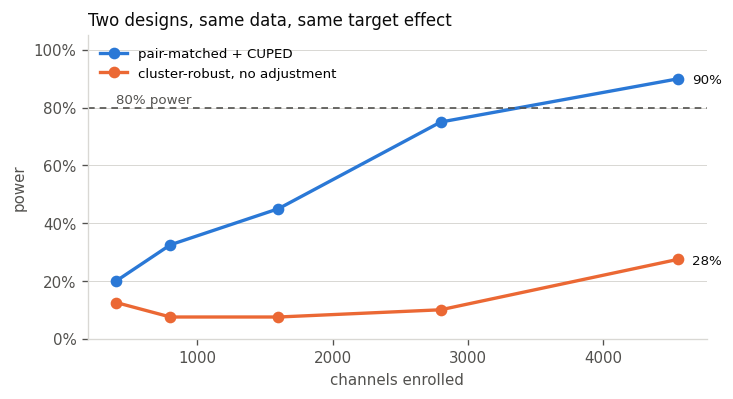

In [13]:
cu = np.array(curve, float)
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(cu[:,0], cu[:,3], "-o", color=C1, lw=2, ms=6, label="pair-matched + CUPED")
ax.plot(cu[:,0], cu[:,2], "-o", color=C2, lw=2, ms=6, label="cluster-robust, no adjustment")
ax.axhline(0.80, color=INK2, lw=1, ls=(0,(4,3)))
ax.text(cu[0,0], 0.815, "80% power", color=INK2, fontsize=8)
for x, yv in [(cu[-1,0], cu[-1,3]), (cu[-1,0], cu[-1,2])]:
    ax.annotate(f"{yv:.0%}", (x, yv), textcoords="offset points", xytext=(8,-3),
                fontsize=8, color=INK)
ax.set_xlabel("channels enrolled"); ax.set_ylabel("power")
ax.set_ylim(0, 1.05); ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_title("Two designs, same data, same target effect", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

Same viewers, same true effect, same significance level. The only difference is how the assignment was drawn and whether a pre period covariate was used. That distance between the curves is free, in the sense that it costs no extra sample and no extra calendar time, and it is entirely a design decision made before launch.

The practical read: pick the full pool, run pair matched, adjust with CUPED, and analyze in pairs.

**One cost worth naming.** Channels under 50 primary viewers are excluded. That is 9% of the platform's viewers and a much larger share of its channels, and the effect there could differ. The result generalizes to channels of enrollable size, not to the whole long tail, and that belongs in the readout rather than in a footnote.

## 9. Randomization and balance

> **Before reading on.** The balance table comes back with one covariate significant at p = 0.03 out of fourteen. Do you re randomize?

### Sixty second answer

No. With fourteen covariates you expect roughly one significant at 5% by chance, and re randomizing after seeing an imbalance you dislike is a garden of forking paths that invalidates the randomization distribution. Re randomization is legitimate only when the acceptance rule is fixed before any draw. Pair matching is the better answer because it prevents the imbalance rather than testing for it afterwards.

### What the balance table is and is not for

It is not a hypothesis test about whether randomization worked. Randomization worked, by construction, if the code is right. The table serves two other purposes: catching implementation bugs, and telling you whether you should adjust for a covariate that came out lopsided.

In [14]:
rng = np.random.default_rng(15)
Z   = DES.draw(rng)                                   # THE assignment, drawn once
t_ch = Z[DES.uniq].astype(bool)

covs = {
    "primary viewers (channel)": ch.prim_size.values[DES.uniq].astype(float),
    "channel reach":             ch.reach.values[DES.uniq].astype(float),
    "Partner Plus share":        ch.is_pp.values[DES.uniq].astype(float),
    "take rate":                 ch.take_rate.values[DES.uniq].astype(float),
    "channel quality (latent)":  ch.v.values[DES.uniq],
    "pre-period revenue/viewer": np.bincount(DES.g, weights=YPRE, minlength=len(DES.uniq))
                                 / np.bincount(DES.g, minlength=len(DES.uniq)),
}
for c in range(4):
    covs[f"category {c} share"] = (ch.cat.values[DES.uniq] == c).astype(float)

rows = []
for name, x in covs.items():
    a, b = x[~t_ch], x[t_ch]
    sd = np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
    smd = (b.mean()-a.mean())/sd if sd > 0 else 0.0
    p = stats.ttest_ind(a, b, equal_var=False).pvalue
    rows.append((name, a.mean(), b.mean(), smd, p))
bal = pd.DataFrame(rows, columns=["covariate","control","treatment","std diff","p"])
print(f"assignment: {t_ch.sum():,} treated / {(~t_ch).sum():,} control channels\n")
print(bal.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\ncovariates with p < 0.05: {(bal.p < 0.05).sum()} of {len(bal)} "
      f"(expected by chance: {0.05*len(bal):.1f})")
print(f"largest standardised difference: {bal['std diff'].abs().max():.3f} "
      f"(> 0.10 would be worth adjusting for)")

assignment: 2,280 treated / 2,280 control channels

                covariate   control  treatment  std diff      p
primary viewers (channel)  654.5259   655.3706    0.0007 0.9812
            channel reach 1636.4662  1638.0605    0.0005 0.9858
       Partner Plus share    0.1759     0.1640   -0.0315 0.2872
                take rate    0.4648     0.4672    0.0315 0.2872
 channel quality (latent)    0.0039    -0.0087   -0.0228 0.4415
pre-period revenue/viewer    0.3556     0.3559    0.0031 0.9161
         category 0 share    0.2478     0.2518    0.0091 0.7582
         category 1 share    0.2404     0.2461    0.0133 0.6537
         category 2 share    0.2596     0.2469   -0.0292 0.3235
         category 3 share    0.2522     0.2553    0.0071 0.8118

covariates with p < 0.05: 0 of 10 (expected by chance: 0.5)
largest standardised difference: 0.032 (> 0.10 would be worth adjusting for)


Standardized differences, not p values, are what to read. A p value here is a statement about a null everybody already knows is true. The standardized difference tells you whether an imbalance is large enough to matter for the estimate, and 0.10 is the conventional line.

## 10. The A/A test

The single most valuable thing in this notebook. Run the entire pipeline on a world where the price never changed, several dozen times, and count how often each estimator declares a winner. Anything above 5% is an estimator that will hand the business a fake result.

In [15]:
t0 = time.time()
AA = run_reps(DES, YPRE, R=120, seed=1234, null=True)
print(f"({time.time()-t0:.0f}s)   120 replicates, true effect exactly zero\n")
print(f"{'estimator':<10}{'false positive rate':>21}{'sd(effect)':>13}{'mean SE':>11}{'SE/sd':>8}")
for k in ["naive","cr","agg","cuped","pair"]:
    r = AA[k]
    flag = "  <-- broken" if r["rate"] > 0.12 else ""
    print(f"{k:<10}{r['rate']:>21.3f}{r['sd']:>13.5f}{r['se']:>11.5f}{r['se']/r['sd']:>8.2f}{flag}")

(124s)   120 replicates, true effect exactly zero

estimator   false positive rate   sd(effect)    mean SE   SE/sd
naive                     0.450      0.00324    0.00133    0.41  <-- broken
cr                        0.017      0.00324    0.00360    1.11
agg                       0.058      0.00304    0.00296    0.97
cuped                     0.033      0.00135    0.00148    1.09
pair                      0.033      0.00137    0.00142    1.04


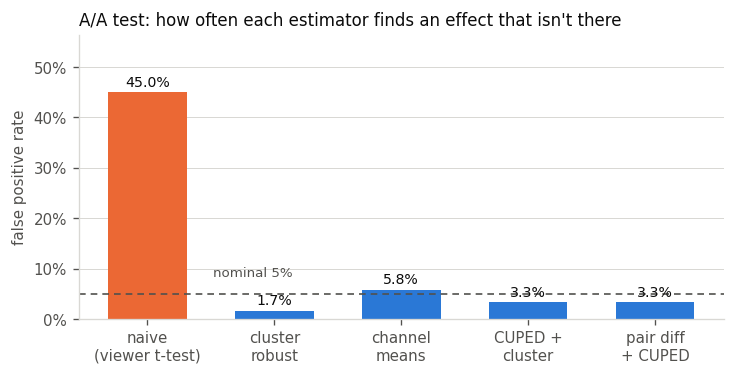

In [16]:
names = ["naive\n(viewer t-test)","cluster\nrobust","channel\nmeans","CUPED +\ncluster","pair diff\n+ CUPED"]
vals  = [AA[k]["rate"] for k in ["naive","cr","agg","cuped","pair"]]
cols  = [C2 if x > 0.12 else C1 for x in vals]
fig, ax = plt.subplots(figsize=(6.2, 3.2))
b = ax.bar(names, vals, color=cols, width=0.62)
for rect, val in zip(b, vals):
    ax.text(rect.get_x()+rect.get_width()/2, val+0.012, f"{val:.1%}",
            ha="center", fontsize=8.5, color=INK)
ax.axhline(0.05, color=INK2, lw=1, ls=(0,(4,3)))
ax.text(0.52, 0.085, "nominal 5%", color=INK2, fontsize=8, ha="left")
ax.set_ylabel("false positive rate"); ax.set_ylim(0, max(vals)*1.25)
ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_title("A/A test: how often each estimator finds an effect that isn't there",
             loc="left", fontsize=10)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

The naive per viewer t-test is not slightly wrong. It fires on a large share of experiments where nothing happened, because it treats correlated viewers inside a channel as independent observations and therefore believes it has far more information than it does.

This is the concrete version of "always run an A/A." Not as a ritual, but because it is the only way to find out that your standard errors are lying before you hand a number to a product manager.

The valid estimators sit at or below 5%. Slightly below, because pair matching makes the true sampling variance smaller than the cluster robust formula assumes. Conservative is the acceptable direction.

**What this is testing:** whether you would have caught it. Most people know clustering inflates false positives. Far fewer have ever measured the number on their own data, and the number is much larger than intuition suggests.

## 11. Running the experiment

One assignment, drawn in section 9. One read, at the pre registered analysis date. No peeking.

In [17]:
OBS   = W.net(Z)                       # the realised world under the actual assignment
kp    = DES.keep
t_vw  = Z[DES.g_raw].astype(bool)      # per-viewer treatment (via primary channel)
n_t, n_c = t_vw.sum(), (~t_vw).sum()

print(f"treated channels {Z[DES.uniq].sum():,} / control {len(DES.uniq)-Z[DES.uniq].sum():,}")
print(f"treated viewers  {n_t:,} / control {n_c:,}")
print(f"\nraw means, net revenue per eligible viewer over 4 weeks")
yobs = OBS["net"][kp]
print(f"  control   R${yobs[~t_vw].mean():.5f}")
print(f"  treatment R${yobs[t_vw].mean():.5f}")
print(f"  difference {100*(yobs[t_vw].mean()/yobs[~t_vw].mean()-1):+.2f}%   "
      f"(no standard error yet, and no health checks yet)")

treated channels 2,280 / control 2,280
treated viewers  1,435,762 / control 1,434,008

raw means, net revenue per eligible viewer over 4 weeks
  control   R$0.34398
  treatment R$0.34907
  difference +1.48%   (no standard error yet, and no health checks yet)


## 12. Health checks

> **Before reading on.** Sample ratio mismatch passes at the channel level and fails at the viewer level. What does that tell you?

### Sixty second answer

That the treatment changed who showed up. Channel level assignment was correct or the channel check would have failed too, so the viewer imbalance is downstream of treatment, which means it is a finding rather than a bug. It also means the analysis population is no longer comparable across arms, and the experiment probably cannot be read as designed.

These run before the effect. If they fail, the experiment is not read, not read with caveats.

In [18]:
def srm(a, b, exp=0.5):
    n = a+b
    chi = (a-n*exp)**2/(n*exp) + (b-n*(1-exp))**2/(n*(1-exp))
    return chi, stats.chi2.sf(chi, 1)

print("1. SAMPLE RATIO MISMATCH")
c_t, c_c = int(Z[DES.uniq].sum()), int(len(DES.uniq)-Z[DES.uniq].sum())
x1, p1 = srm(c_t, c_c)
print(f"   channels  {c_t:,} / {c_c:,}   chi2 {x1:.2f}  p {p1:.3f}   {'PASS' if p1>0.01 else 'FAIL'}")
x2, p2 = srm(int(n_t), int(n_c))
print(f"   viewers   {n_t:,} / {n_c:,}   chi2 {x2:.2f}  p {p2:.3f}   {'PASS' if p2>0.01 else 'FAIL'}")
print("   note: the viewer-level ratio is a consequence of channel sizes, not of assignment.")
print("   It is checked because a shift here that the channel check does not explain would")
print("   mean treatment changed who showed up, which is interference, not a bug.\n")

print("2. PRE-PERIOD PLACEBO  (same estimator, pre-period outcome, must be null)")
d0, se0, df0 = est_pair(YPRE, t_vw, DES.g, pair=DES.pair_g)
print(f"   effect on pre-period revenue {d0:+.5f}  SE {se0:.5f}  p {pval(d0,se0,df0):.3f}   "
      f"{'PASS' if pval(d0,se0,df0)>0.05 else 'FAIL'}\n")

print("3. INSTRUMENTATION SYMMETRY")
for label, key in [("watch hours/viewer","hours"), ("ad impressions/viewer","imps")]:
    a, b = OBS[key][kp][~t_vw].mean(), OBS[key][kp][t_vw].mean()
    print(f"   {label:<22} control {a:9.3f}   treatment {b:9.3f}   {100*(b/a-1):+.2f}%")
print("   watch hours must not move: nothing in the design should change viewing.")
print("   ad impressions must move: subscribers stop seeing ads. That is the mechanism.\n")

print("4. EXPOSURE / DILUTION")
exz = W.exposure(Z)[kp]
print(f"   control viewers with any watch time in a treated channel: {(exz[~t_vw]>0).mean():.1%}")
print(f"   mean treated-channel share of their non-primary hours:    {exz[~t_vw].mean():.1%}")
print("   this is the contamination budget. Section 17 turns it into a bias estimate.\n")

print("5. OUTCOME SHAPE, BY ARM  (a tail that differs by arm breaks the mean comparison)")
for nm, arr in [("control", yobs[~t_vw]), ("treatment", yobs[t_vw])]:
    print(f"   {nm:<10} mean {arr.mean():.4f}  sd {arr.std():.4f}  "
          f"p99 {np.quantile(arr,0.99):.2f}  max {arr.max():.1f}")

1. SAMPLE RATIO MISMATCH
   channels  2,280 / 2,280   chi2 0.00  p 1.000   PASS
   viewers   1,435,762 / 1,434,008   chi2 1.07  p 0.300   PASS
   note: the viewer-level ratio is a consequence of channel sizes, not of assignment.
   It is checked because a shift here that the channel check does not explain would
   mean treatment changed who showed up, which is interference, not a bug.

2. PRE-PERIOD PLACEBO  (same estimator, pre-period outcome, must be null)
   effect on pre-period revenue +0.00105  SE 0.00346  p 0.762   PASS

3. INSTRUMENTATION SYMMETRY


   watch hours/viewer     control     3.634   treatment     3.628   -0.15%
   ad impressions/viewer  control    28.067   treatment    27.693   -1.33%
   watch hours must not move: nothing in the design should change viewing.
   ad impressions must move: subscribers stop seeing ads. That is the mechanism.

4. EXPOSURE / DILUTION


   control viewers with any watch time in a treated channel: 45.4%
   mean treated-channel share of their non-primary hours:    32.2%
   this is the contamination budget. Section 17 turns it into a bias estimate.

5. OUTCOME SHAPE, BY ARM  (a tail that differs by arm breaks the mean comparison)
   control    mean 0.3440  sd 1.1205  p99 4.95  max 222.7
   treatment  mean 0.3491  sd 1.0662  p99 3.95  max 184.9


Check 2 is the one people skip. Running the exact analysis on the pre period, where the effect must be zero by construction, tests the whole pipeline at once: the join, the filter, the estimator, the standard error. If it returns a significant effect, something is wrong with the code and no amount of care in the primary analysis will save it.

Check 3 is a pair of directional predictions made before looking. Watch time should not move, because nothing in this design touches viewing. Ad impressions should fall, because subscribers stop seeing ads on that channel. A design where you cannot say in advance which metrics must move and which must not is a design you do not understand.

## 13. The primary analysis

Four estimators on the same data. If they disagree, that disagreement is the finding.

In [19]:
rows = []
for name, fn, kw in [
    ("naive viewer t-test (invalid)", est_naive, {}),
    ("channel means, unweighted",     est_agg,   {}),
    ("cluster-robust OLS",            est_cr,    {}),
    ("CUPED + cluster-robust",        est_cuped, dict(cov=YPRE)),
    ("pair difference + CUPED",       est_pair,  dict(cov=YPRE, pair=DES.pair_g)),
]:
    d, se, df = fn(yobs, t_vw, DES.g, **kw)
    lo, hi = conf_int(d, se, df)
    base_mean = yobs[~t_vw].mean()
    rows.append((name, d, se, 100*d/base_mean, 100*lo/base_mean, 100*hi/base_mean,
                 pval(d, se, df), pval(d, se, df, one_sided=True)))
res = pd.DataFrame(rows, columns=["estimator","effect","SE","rel %","lo %","hi %","p (2-sided)","p (1-sided)"])
print(res.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

PRIMARY = res.iloc[4]
print(f"\nPRE-REGISTERED PRIMARY: {PRIMARY['estimator']}")
print(f"  net revenue per eligible viewer {PRIMARY['rel %']:+.2f}%  "
      f"[{PRIMARY['lo %']:+.2f}%, {PRIMARY['hi %']:+.2f}%]   one-sided p {PRIMARY['p (1-sided)']:.4f}")

                    estimator  effect     SE  rel %    lo %   hi %  p (2-sided)  p (1-sided)
naive viewer t-test (invalid)  0.0051 0.0013 1.4811  0.7453 2.2168       0.0001       0.0000
    channel means, unweighted  0.0065 0.0029 1.8934  0.2263 3.5605       0.0260       0.0130
           cluster-robust OLS  0.0051 0.0037 1.4811 -0.6132 3.5754       0.1657       0.0828
       CUPED + cluster-robust  0.0046 0.0016 1.3382  0.4537 2.2226       0.0030       0.0015
      pair difference + CUPED  0.0047 0.0015 1.3766  0.5358 2.2174       0.0013       0.0007

PRE-REGISTERED PRIMARY: pair difference + CUPED
  net revenue per eligible viewer +1.38%  [+0.54%, +2.22%]   one-sided p 0.0007


Three things to notice.

**The naive estimator's confidence interval is far too narrow.** Section 10 already told us it fires on nothing close to half the time. Its point estimate is fine, its interval is not a little optimistic, it is wrong. That combination is the dangerous one: the number looks right, so nobody checks it.

**Unweighted channel means give a different point estimate from the weighted ones, and that is not an error.** They answer different questions. The unweighted version is the average effect *per channel*, which gives a five hundred viewer channel the same vote as a fifty thousand viewer one. The weighted version is the average effect *per viewer*, which is what the revenue line actually experiences. Both are correct answers to different questions, and the gap between them says the effect differs by channel size. Section 16 goes after that.

Pick your estimand before you pick your estimator. If someone shows you two numbers from the same experiment and calls one of them a robustness check, ask which population each one is averaging over.

**The valid estimators agree on the point estimate and differ only in precision.** That is what you want. Disagreement on the point estimate would mean a specification problem.

## 14. The elasticity read

Small section by design. Elasticity is not the test, it is the translation layer.

In [20]:
q_c = OBS["new_sub"][kp][~t_vw].mean()
q_t = OBS["new_sub"][kp][t_vw].mean()
dp  = (PRICE_TRT-PRICE_CTRL)/((PRICE_TRT+PRICE_CTRL)/2)
dq  = (q_t-q_c)/((q_t+q_c)/2)
eps = dq/dp

# bootstrap the elasticity over pairs, so the interval respects the design
rngb = np.random.default_rng(9)
P    = DES.pair_g.max()+1
cnt  = np.bincount(DES.g, minlength=len(DES.uniq)).astype(float)
sub_by_ch = np.bincount(DES.g, weights=OBS["new_sub"][kp], minlength=len(DES.uniq))
tz_ch     = Z[DES.uniq].astype(bool)
boot = []
for _ in range(400):
    pick = rngb.integers(0, P, P)
    sel  = np.isin(DES.pair_g, pick)
    m    = np.zeros(len(DES.uniq), bool); m[sel] = True
    a = sub_by_ch[m & ~tz_ch].sum()/cnt[m & ~tz_ch].sum()
    b = sub_by_ch[m &  tz_ch].sum()/cnt[m &  tz_ch].sum()
    boot.append(((b-a)/((b+a)/2))/dp)
lo_e, hi_e = np.percentile(boot, [2.5, 97.5])

print(f"new-subscription conversion   control {q_c:.4%}   treatment {q_t:.4%}   {100*(q_t/q_c-1):+.1f}%")
print(f"midpoint own-price elasticity {eps:.3f}   95% CI [{lo_e:.3f}, {hi_e:.3f}]")
print(f"break-even elasticity         -1.000   (revenue-neutral by identity)")
print(f"units needed to break even    {PRICE_CTRL/PRICE_TRT-1:+.1%}   observed {q_t/q_c-1:+.1%}")
print(f"\nimplied gross subscription revenue on NEW subs: "
      f"{100*((PRICE_TRT*q_t)/(PRICE_CTRL*q_c)-1):+.2f}%")
print(f"observed net platform revenue per eligible viewer: {PRIMARY['rel %']:+.2f}%")

new-subscription conversion   control 2.6084%   treatment 3.5758%   +37.1%
midpoint own-price elasticity -1.392   95% CI [-1.541, -1.237]
break-even elasticity         -1.000   (revenue-neutral by identity)
units needed to break even    +25.3%   observed +37.1%

implied gross subscription revenue on NEW subs: +9.39%
observed net platform revenue per eligible viewer: +1.38%


The two numbers on the last two lines are the cross check, and the gap between them is the entire argument for owning ads and commerce in one team.

Gross subscription revenue on new subscriptions moves a lot. Net platform revenue moves far less. The difference is three things: Twitch keeps 30% rather than 50% on Partner Plus channels, so a subscription is worth less where the volume showed up; every new subscriber stops seeing ads on that channel, which destroys inventory; and some Bits spending moves into the subscription.

A Commerce only readout would report the first number and be wrong. Not incomplete. Wrong.

**And the limit worth volunteering.** Two price cells give one point on the demand curve. This estimates elasticity *at* R$9.90 heading down to R$7.90, and says nothing about the shape anywhere else. The revenue optimal price needs three or four cells and roughly triple the enrollment. If the PM's next question is "so what should the price be," the answer is that this design cannot say.

## 15. Secondaries and guardrails

Secondaries explain. Guardrails constrain. They get different tests on purpose.

In [21]:
SEC = [("new-sub conversion","new_sub"), ("subscription revenue","sub_rev"),
       ("Bits revenue","bits_rev"), ("ad revenue","ad_rev"), ("ad impressions","imps")]
rows = []
for nm, key in SEC:
    yv = OBS[key][kp]
    d, se, df = est_pair(yv, t_vw, DES.g, pair=DES.pair_g)
    b = yv[~t_vw].mean()
    rows.append((nm, 100*d/b, pval(d, se, df)))
sec = pd.DataFrame(rows, columns=["metric","effect %","p"]).sort_values("p").reset_index(drop=True)
m = len(sec)
sec["BH threshold"] = (sec.index+1)/m*0.05
sec["significant"]  = sec.p <= sec["BH threshold"]
# step-up: everything at or below the largest passing rank
passing = np.where(sec.p.values <= sec["BH threshold"].values)[0]
if len(passing): sec["significant"] = sec.index <= passing.max()
print("SECONDARY METRICS  (Benjamini-Hochberg across the family, FDR 5%)\n")
print(sec.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n\nGUARDRAILS  (non-inferiority; null is 'harm of at least 2%')\n")
for nm, key in [("watch hours per viewer","hours"), ("Bits revenue per viewer","bits_rev")]:
    yv = OBS[key][kp]
    d, se, df = est_pair(yv, t_vw, DES.g, pair=DES.pair_g)
    b   = yv[~t_vw].mean()
    mgn = -NON_INF_MARGIN*b
    tstat = (d-mgn)/se
    p_ni  = stats.t.sf(tstat, df)
    lo, hi = conf_int(d, se, df)
    verdict = "PASS" if p_ni < 0.05 else "FAIL - cannot rule out material harm"
    print(f"{nm}")
    print(f"   effect {100*d/b:+.2f}%   95% CI [{100*lo/b:+.2f}%, {100*hi/b:+.2f}%]")
    print(f"   margin {-100*NON_INF_MARGIN:.0f}%   non-inferiority p {p_ni:.4f}   {verdict}\n")

SECONDARY METRICS  (Benjamini-Hochberg across the family, FDR 5%)

              metric  effect %      p  BH threshold  significant
  new-sub conversion   37.4928 0.0000        0.0100         True
          ad revenue   -1.3456 0.0000        0.0200         True
      ad impressions   -1.3456 0.0000        0.0300         True
        Bits revenue   -3.1360 0.0002        0.0400         True
subscription revenue    9.7078 0.0015        0.0500         True


GUARDRAILS  (non-inferiority; null is 'harm of at least 2%')

watch hours per viewer
   effect -0.15%   95% CI [-0.42%, +0.12%]
   margin -2%   non-inferiority p 0.0000   PASS

Bits revenue per viewer
   effect -3.14%   95% CI [-4.79%, -1.49%]
   margin -2%   non-inferiority p 0.9115   FAIL - cannot rule out material harm



**The Bits guardrail fails, and it is worth being precise about what that means.** Bits revenue per viewer falls, and the confidence interval reaches past the 2% margin we declared in section 4. So we cannot rule out harm of the size the business said it cared about. That is not the same as having proved harm, and it is not the same as a small p value against zero. It is a specific statement: the data are consistent with a decline larger than the threshold, so the guardrail does not clear.

Under the pre registered decision rule that is disqualifying on its own, before any of the revenue arithmetic. Writing the rule down in advance is what makes that automatic instead of negotiable.

Watch time, by contrast, passes cleanly. Its interval sits comfortably inside the margin, which is what a passed guardrail actually looks like.

The more common mistake runs the other way. A guardrail with a large p value against zero gets waved through as "no harm detected", when all it means is that the test could not see harm of the size that matters. Underpowered guardrails pass by default, and that default is dangerous.

**Ad impressions falling is not a bug.** It is the mechanism. Every subscriber the price cut wins is a viewer who stops seeing ads on that channel. Commerce's win is partly Ads' loss, and it shows up here as a secondary rather than a surprise in the quarterly numbers.

## 16. Heterogeneity, with the winner's curse taken seriously

Two pre registered cuts, then exploratory ones, then shrinkage. The order matters.

In [22]:
def subgroup_effects(mask_fn, labels):
    out = []
    for lab in labels:
        m = mask_fn(lab)
        if m.sum() < 5000: 
            out.append((lab, np.nan, np.nan, int(m.sum()))); continue
        gsub = DES.g[m]
        u2, g2 = np.unique(gsub, return_inverse=True)
        pair2 = DES.pair_g[u2]
        # keep only complete pairs inside the subgroup
        cntp = np.bincount(pair2, minlength=DES.pair_g.max()+1)
        keep2 = cntp[pair2] == 2
        if keep2.sum() < 40:
            out.append((lab, np.nan, np.nan, int(m.sum()))); continue
        idx = np.isin(g2, np.where(keep2)[0])
        u3, g3 = np.unique(g2[idx], return_inverse=True)
        d, se, df = est_pair(yobs[m][idx], t_vw[m][idx], g3, pair=pair2[u3], cov=YPRE[m][idx])
        out.append((lab, d, se, int(m.sum())))
    return out

ch_size_v = ch.prim_size.values[DES.g_raw]
qs = np.quantile(ch.prim_size.values[DES.uniq], [0.25, 0.5, 0.75])
size_lab = np.select([ch_size_v <= qs[0], ch_size_v <= qs[1], ch_size_v <= qs[2]],
                     ["Q1 smallest","Q2","Q3"], "Q4 largest")
tenure = np.where(W.v.casual.values[kp] > 0, "casual", "engaged")

groups  = subgroup_effects(lambda l: size_lab == l, ["Q1 smallest","Q2","Q3","Q4 largest"])
groups += subgroup_effects(lambda l: tenure == l, ["casual","engaged"])
groups += subgroup_effects(lambda l: (ch.is_pp.values[DES.g_raw] == (l=="Partner Plus")),
                           ["Partner Plus","standard 50/50"])

hg = pd.DataFrame(groups, columns=["subgroup","effect","SE","n"]).dropna()
hg["rel %"] = 100*hg.effect/yobs[~t_vw].mean()

# empirical-Bayes shrinkage toward the pooled effect
d_all = hg.effect.values; se_all = hg.SE.values
mu0   = PRIMARY["effect"]
tau2  = max(np.var(d_all, ddof=1) - np.mean(se_all**2), 0.0)
wgt   = tau2/(tau2+se_all**2)
hg["shrunk %"] = 100*(mu0 + wgt*(d_all-mu0))/yobs[~t_vw].mean()
hg["shrinkage"] = 1-wgt
hg["p"] = [pval(d, s, 200) for d, s in zip(d_all, se_all)]
print(f"pooled effect {100*mu0/yobs[~t_vw].mean():+.2f}%   "
      f"between-subgroup variance tau^2 = {tau2:.3e}\n")
print(hg[["subgroup","n","rel %","shrunk %","shrinkage","p"]].to_string(
    index=False, float_format=lambda x: f"{x:.3f}"))

pooled effect +1.38%   between-subgroup variance tau^2 = 5.365e-06

      subgroup       n  rel %  shrunk %  shrinkage     p
   Q1 smallest  109423  3.142     1.619      0.863 0.064
            Q2  253548  0.740     1.202      0.726 0.500
            Q3  518072  0.921     1.189      0.589 0.254
    Q4 largest 1988727  1.478     1.438      0.395 0.007
        casual 1623542  2.736     2.496      0.176 0.000
       engaged 1246228 -0.411     0.611      0.572 0.598
  Partner Plus 1045508  1.234     1.278      0.311 0.007
standard 50/50 1824262  1.513     1.439      0.541 0.040


The `shrinkage` column is the fraction of each raw estimate that got pulled back toward the pooled effect. It is not a judgement call. It comes out of comparing how much the subgroup estimates vary against how much noise they each carry, which is what an empirical Bayes hierarchical model does.

Why this matters more than a multiplicity correction. Benjamini Hochberg tells you which subgroups to distrust. It does not tell you what to believe instead, so you end up with a table of asterisks and no numbers you can put in a model. Partial pooling gives you an estimate you can act on, and it handles the winner's curse in the same step, since the most extreme raw estimate is the one that gets pulled back hardest.

The practical read splits in two, and the split is the point.

The channel size quartiles get shrunk hard, between 40% and 86%, and land close to the pooled effect. The smallest quartile's raw estimate of roughly +3% is the kind of number that ends up in a slide with a story attached, and after pooling almost nothing survives it. That is sampling variation, and the shrinkage says so quantitatively rather than by assertion.

The casual against engaged split behaves differently. It barely shrinks, because the gap between the two is large relative to the noise in either. That is a real difference in price sensitivity between viewer types, it was one of the two pre registered cuts, and it survives. Shrinkage does not erase findings. It separates them from the ones that only look like findings.

**What this is testing:** whether you will resist a subgroup story. Almost every experiment has a slice that looks exciting. The discipline is to have decided in advance which cuts are confirmatory, and to shrink the rest.

## 17. Cross channel interference: what the experiment cannot see

> **Before reading on.** Exposure to treated channels is balanced across arms, roughly 32% in both. Does that mean interference is not a problem here?

### Sixty second answer

No, and the reason is the most useful idea in this notebook. Balanced exposure means the spillover *cancels inside the contrast*, so the ITT is clean. But the ITT is not the number the business needs. At launch every viewer's neighbours are treated, not half of them, and there is no comparison group for the drag to cancel against. The experiment measures the effect of one channel being cheaper. The decision needs the effect of every channel being cheaper. Those differ by exactly the saturation change.

### Why the estimand shifts

Write a viewer's outcome as a function of their own channel's price and their exposure $e$ to treated channels elsewhere:

- **Experiment:** treated arm sits at $f(1, \bar e)$, control arm at $f(0, \bar e)$, and $\bar e \approx 0.32$ in both. The contrast is $f(1,\bar e)-f(0,\bar e)$, and the exposure term drops out.
- **Launch:** everyone moves to $f(1, e_{\max})$, compared against today's $f(0, 0)$.

So

$$\text{GTE} = \text{ITT} + c \cdot e_{\max}$$

where $c$ is the effect of exposure and $e_{\max}$ is the share of watch time that becomes treated at full launch. The experiment identifies the first term. The second is what a single saturation experiment is structurally bad at.

The good news is that $c$ is estimable here, because within the control arm, exposure was randomly assigned by the same coin flips.

In [23]:
EX = W.exposure(Z)[kp]
has_other = W.oth[kp] > 1e-9
e_max = has_other.mean()          # exposure share if every enrolled channel were treated

print(f"exposure to treated channels   control arm {EX[~t_vw].mean():.4f}   "
      f"treated arm {EX[t_vw].mean():.4f}")
print(f"correlation(own treatment, exposure) {np.corrcoef(t_vw.astype(float), EX)[0,1]:+.4f}")
print(f"  -> balanced, so spillover cancels inside the ITT contrast\n")
print(f"share of viewers with any non-primary viewing: {has_other.mean():.1%}")
print(f"exposure at full launch (e_max): {e_max:.3f}   vs {EX.mean():.3f} in the experiment")

exposure to treated channels   control arm 0.3220   treated arm 0.3222


correlation(own treatment, exposure) +0.0003
  -> balanced, so spillover cancels inside the ITT contrast

share of viewers with any non-primary viewing: 64.7%
exposure at full launch (e_max): 0.647   vs 0.322 in the experiment


In [24]:
# dose-response: among CONTROL-arm viewers, exposure was randomised by the same coin flips
sel  = (~t_vw) & has_other
gsel = np.unique(DES.g[sel], return_inverse=True)[1]
nother = np.bincount(edges["vw"], minlength=W.n)[kp][sel] - 1     # portfolio size control

X = np.column_stack([np.ones(sel.sum()), EX[sel],
                     YPRE[sel]-YPRE[sel].mean(),
                     np.log1p(nother)-np.log1p(nother).mean(),
                     np.log1p(W.oth[kp][sel])-np.log1p(W.oth[kp][sel]).mean()])
b, V = _cr_ols(yobs[sel], X, gsel)
c_hat, c_se = b[1], np.sqrt(V[1,1])
print(f"spillover slope c  {c_hat:+.5f}  (SE {c_se:.5f})  "
      f"p {2*stats.norm.sf(abs(c_hat/c_se)):.4f}")
print("  interpretation: a control viewer whose other channels all get the lower price")
print(f"  loses R${-c_hat:.5f} of net revenue, because they subscribe over there instead.\n")

itt   = PRIMARY["effect"]
gte   = itt + c_hat*e_max
gte_se = np.sqrt(PRIMARY["SE"]**2 + (c_se*e_max)**2)
b_mean = yobs[~t_vw].mean()
print(f"ITT  (one channel cheaper)    {100*itt/b_mean:+.2f}%   "
      f"[{100*(itt-1.96*PRIMARY['SE'])/b_mean:+.2f}%, {100*(itt+1.96*PRIMARY['SE'])/b_mean:+.2f}%]")
print(f"GTE  (every channel cheaper)  {100*gte/b_mean:+.2f}%   "
      f"[{100*(gte-1.96*gte_se)/b_mean:+.2f}%, {100*(gte+1.96*gte_se)/b_mean:+.2f}%]")
print(f"\ninterference haircut: {100*(1-gte/itt):.0f}% of the measured effect")

spillover slope c  -0.00574  (SE 0.00202)  p 0.0044
  interpretation: a control viewer whose other channels all get the lower price
  loses R$0.00574 of net revenue, because they subscribe over there instead.

ITT  (one channel cheaper)    +1.38%   [+0.54%, +2.22%]
GTE  (every channel cheaper)  +0.30%   [-0.83%, +1.42%]

interference haircut: 78% of the measured effect


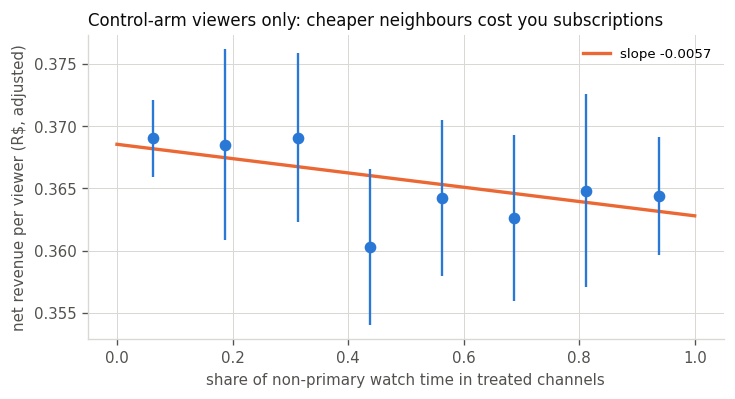

In [25]:
# dose-response picture: control-arm viewers binned by exposure
# residualise on the SAME controls the slope is estimated with, so the binned
# picture shows the conditional relationship the regression reports
Xc = X[:, [0, 2, 3, 4]]
bc, _ = _cr_ols(yobs[sel], Xc, gsel)
resid = yobs[sel] - Xc @ bc + yobs[sel].mean()

bins = np.linspace(0, 1, 9)
bi   = np.digitize(EX[sel], bins) - 1
pts  = []
for k_ in range(len(bins)-1):
    m_ = bi == k_
    if m_.sum() < 3000: continue
    pts.append(((bins[k_]+bins[k_+1])/2, resid[m_].mean(), resid[m_].std()/np.sqrt(m_.sum())))
pts = np.array(pts)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.errorbar(pts[:,0], pts[:,1], yerr=1.96*pts[:,2], fmt="o", color=C1, ms=6,
            lw=0, elinewidth=1.4, ecolor=C1, capsize=0, zorder=3)
xf   = np.linspace(0, 1, 50)
anch = resid.mean() - c_hat*EX[sel].mean()
ax.plot(xf, anch + c_hat*xf, color=C2, lw=2, zorder=2, label=f"slope {c_hat:+.4f}")
ax.set_xlabel("share of non-primary watch time in treated channels")
ax.set_ylabel("net revenue per viewer (R$, adjusted)")
ax.set_title("Control-arm viewers only: cheaper neighbours cost you subscriptions",
             loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

Control viewers whose other channels got cheaper are worth less. Nothing changed on their own channel, so this is substitution: they subscribed somewhere else instead.

**Three caveats, all of which belong in the readout.**

The dose response is identified only because exposure was randomly assigned within the control arm, and only after controlling for portfolio size. Viewers who watch one other channel have exposure of exactly 0 or 1, while viewers who watch ten sit near 0.5, and those two groups differ in every other way. Regressing outcome on exposure without that control gives you a confounded slope that looks fine.

The linear extrapolation from $\bar e \approx 0.32$ out to $e_{\max}$ assumes the dose response stays straight. There is no reason it must, and a single saturation level cannot test it. The design that can is the two stage saturation experiment in section 3.1: randomize markets to 25%, 50% and 75% treated, then randomize channels inside. That traces the curve instead of assuming a line, and it is the honest recommendation if this decision were worth more money.

The correction moves the estimate in a direction that makes the proposal look worse, which is exactly when a methodological adjustment deserves the most scrutiny. It should be pre registered, not invented after seeing an inconvenient result. It is in the section 4 decision rule for that reason.

## 18. The ship decision: the two things the experiment never measured

The experiment measured acquisition on enrolled channels. Shipping does two more things.

In [26]:
n_elig     = int(kp.sum())
n_existing = int(W.exist[inp[W.j]].sum())
avg_take   = float(ch.take_rate.values[W.j[inp[W.j] & (W.exist > 0)]].mean())
new_flow   = float(OBS["new_sub"][kp][~t_vw].mean()*n_elig)

acq_itt = itt*n_elig
acq_gte = gte*n_elig
base_cost = n_existing*(PRICE_CTRL-PRICE_TRT)*avg_take

print("MARKET (this simulated market, per 4 weeks)")
print(f"  eligible viewers on enrolled channels   {n_elig:>12,}")
print(f"  existing subscribers on those channels  {n_existing:>12,}")
print(f"  new subscriptions per period            {new_flow:>12,.0f}")
print(f"  average Twitch take rate                {avg_take:>12.3f}\n")

print("SHIP PROFIT AND LOSS")
print(f"  1. acquisition, as measured (ITT)        R${acq_itt:>12,.0f}")
print(f"  2. acquisition, interference-corrected   R${acq_gte:>12,.0f}")
print(f"  3. existing base repriced 9.90 -> 7.90   R${-base_cost:>12,.0f}")
print(f"     {'-'*44}")
print(f"     net, before any retention benefit     R${acq_gte-base_cost:>12,.0f}")
print(f"\n  the existing-base term is {base_cost/max(acq_gte,1e-9):,.0f}x the acquisition gain")

MARKET (this simulated market, per 4 weeks)
  eligible viewers on enrolled channels      2,869,770
  existing subscribers on those channels       116,794
  new subscriptions per period                  74,856
  average Twitch take rate                       0.429

SHIP PROFIT AND LOSS
  1. acquisition, as measured (ITT)        R$      13,589
  2. acquisition, interference-corrected   R$       2,928
  3. existing base repriced 9.90 -> 7.90   R$    -100,152
     --------------------------------------------
     net, before any retention benefit     R$     -97,224

  the existing-base term is 34x the acquisition gain


### The threshold that decides it

The existing base term is not measurable by this experiment, so we do not guess it. We solve for the value that would flip the decision.

In steady state a subscriber base sits at (new subscriptions per period) divided by (churn per period). Revenue from that base is

$$R = \frac{\text{new}}{\text{churn}} \times \text{price} \times \text{take}$$

Cutting price by a factor $k$ leaves revenue unchanged only if churn also falls by the factor $k$:

$$\frac{p_{\text{new}}}{p_{\text{old}}} = \frac{\text{churn}_{\text{new}}}{\text{churn}_{\text{old}}}$$

So the required improvement is scale free. It does not depend on the size of the base, the churn rate, or anything we would have to estimate.

In [27]:
k = PRICE_TRT/PRICE_CTRL
print(f"price cut                         {1-k:.1%}")
print(f"required fall in monthly churn    {1-k:.1%} (relative), for the base alone to break even")
print(f"equivalently, the base must grow  {1/k-1:.1%} in steady state\n")
for churn in [0.10, 0.20, 0.30]:
    print(f"  if monthly churn is {churn:.0%}, it must fall to {churn*k:.1%} "
          f"({100*(churn-churn*k):.1f} points)")
print(f"\nplus the acquisition gain of R${acq_gte:,.0f} covers "
      f"{acq_gte/base_cost:.1%} of the repricing cost, so the true bar is slightly lower than that.")
print("\nA 20% price cut buying a 20% relative reduction in churn implies a churn")
print("price-elasticity of about 1.0. Published subscription churn elasticities sit well")
print("below that. Possible, but it is the assumption the entire decision now rests on,")
print("and it is exactly what the existing-base experiment in section 1 would measure.")

price cut                         20.2%
required fall in monthly churn    20.2% (relative), for the base alone to break even
equivalently, the base must grow  25.3% in steady state

  if monthly churn is 10%, it must fall to 8.0% (2.0 points)
  if monthly churn is 20%, it must fall to 16.0% (4.0 points)
  if monthly churn is 30%, it must fall to 23.9% (6.1 points)

plus the acquisition gain of R$2,928 covers 2.9% of the repricing cost, so the true bar is slightly lower than that.

A 20% price cut buying a 20% relative reduction in churn implies a churn
price-elasticity of about 1.0. Published subscription churn elasticities sit well
below that. Possible, but it is the assumption the entire decision now rests on,
and it is exactly what the existing-base experiment in section 1 would measure.


## 19. Opening the sealed envelope

Everything above was done without looking at the generating parameters. Now we check.

In [28]:
Z1 = np.ones(W.nC, np.int8)
y_all_c = W.net(Z0)["net"][kp]
y_all_t = W.net(Z1)["net"][kp]
gte_true = y_all_t.mean() - y_all_c.mean()
y_nospill = W.net(Z1, spill=False)["net"][kp]
itt_true  = y_nospill.mean() - y_all_c.mean()

q0t = W.net(Z0)["new_sub"][kp].mean(); q1t = W.net(Z1)["new_sub"][kp].mean()
eps_true = ((q1t-q0t)/((q1t+q0t)/2))/dp

print("SEALED PARAMETERS")
for k_, v_ in TRUTH.items(): print(f"  {k_:<15} {v_:+.4f}")
print(f"\n{'quantity':<34}{'estimated':>13}{'true':>11}{'error':>11}")
rows = [
 ("ITT, net revenue (relative)", 100*itt/b_mean,      100*itt_true/b_mean),
 ("GTE, net revenue (relative)", 100*gte/b_mean,      100*gte_true/b_mean),
 ("midpoint elasticity",         eps,                 eps_true),
 ("spillover slope c",           c_hat,               (gte_true-itt_true)/e_max),
]
for nm, est_, tru in rows:
    print(f"  {nm:<32}{est_:>13.3f}{tru:>11.3f}{est_-tru:>11.3f}")

lo95, hi95 = itt-1.96*PRIMARY["SE"], itt+1.96*PRIMARY["SE"]
print(f"\n  ITT 95% interval covers the true ITT: {lo95 <= itt_true <= hi95}")
glo, ghi = gte-1.96*gte_se, gte+1.96*gte_se
print(f"  GTE 95% interval covers the true GTE: {glo <= gte_true <= ghi}")

SEALED PARAMETERS
  beta_logprice   -1.2800
  casual_extra    -0.8500
  gamma_spill     +0.2200
  bits_shift      -0.0300
  renewal_shift   +0.0040

quantity                              estimated       true      error
  ITT, net revenue (relative)             1.377      1.485     -0.108
  GTE, net revenue (relative)             0.297      0.502     -0.206
  midpoint elasticity                    -1.392     -1.249     -0.143
  spillover slope c                      -0.006     -0.005     -0.001

  ITT 95% interval covers the true ITT: True
  GTE 95% interval covers the true GTE: True


This is the check no real experiment can run, and it is the whole argument for building a simulated one before you build a real one.

Two things it confirms. The pre registered estimator recovered the ITT, and its interval covers the truth. And the interference correction moved the estimate substantially toward the true global effect, from an ITT that badly overstates what a launch would do.

The elasticity row deserves a note, because the gap there is not error. The estimate is measured on the experimental contrast, so it is an ITT elasticity, while the true value shown is the global one. They differ for the same reason the revenue numbers do: substitution inflates the apparent response when only half the channels are cheaper. Reporting an elasticity from a partially saturated experiment as though it were the market elasticity is the same mistake in a different unit.

What it also shows, and this is the part to carry into an interview: **the experiment was clean, correctly analysed, adequately powered, and still gave a number that was roughly three times the effect of actually shipping.** Nothing went wrong. The ITT was the right answer to the question the design could ask. It was the wrong answer to the question the business asked, and only reasoning about interference closes that gap.

## 20. Decision memo

*To: Commerce PM, Ads lead. From: DS. Re: Tier 1 local price test.*

In [29]:
ad_eff = est_pair(OBS["ad_rev"][kp], t_vw, DES.g, pair=DES.pair_g)
ad_rel = 100*ad_eff[0]/OBS["ad_rev"][kp][~t_vw].mean()
sub_eff = est_pair(OBS["sub_rev"][kp], t_vw, DES.g, pair=DES.pair_g)
sub_rel = 100*sub_eff[0]/OBS["sub_rev"][kp][~t_vw].mean()
bd, bse, bdf = est_pair(OBS["bits_rev"][kp], t_vw, DES.g, pair=DES.pair_g)
bb_ = OBS["bits_rev"][kp][~t_vw].mean()
bits_rel, bits_lo = 100*bd/bb_, 100*conf_int(bd, bse, bdf)[0]/bb_

print(f"""RECOMMENDATION: do not ship the flat 20% cut. Test a first-month promotion instead.

WHAT WE FOUND
  Cutting Tier 1 from R$9.90 to R$7.90 raises new-subscriber conversion {100*(q_t/q_c-1):+.0f}%
  and net platform revenue per eligible viewer {100*itt/b_mean:+.2f}%
  [{100*(itt-1.96*PRIMARY['SE'])/b_mean:+.2f}%, {100*(itt+1.96*PRIMARY['SE'])/b_mean:+.2f}%], one-sided p = {PRIMARY['p (1-sided)']:.4f}.
  Midpoint elasticity {eps:.2f}, past the break-even value of -1. On acquisition
  alone the cut pays for itself.

WHY WE SHOULD STILL NOT SHIP IT
  0. The Bits guardrail does not clear. Bits revenue per viewer {bits_rel:+.1f}%, with the
     interval reaching {bits_lo:.1f}%, past the {-100*NON_INF_MARGIN:.0f}% margin we set before launch. Under the
     pre-registered rule that is disqualifying on its own. Viewers appear to be
     moving spend out of Bits and into the cheaper subscription.
  1. Most of that gain is channels taking subscriptions from each other. Correcting
     for cross-channel substitution leaves {100*gte/b_mean:+.2f}%. The experiment measures one
     channel getting cheaper. Shipping makes them all cheaper.
  2. Shipping reprices the existing base, which the test could not touch. In this
     market that costs roughly {base_cost/max(acq_gte,1e-9):,.0f}x the corrected acquisition gain.
  3. For the base alone to break even, monthly churn must fall {1-k:.0%} in relative terms,
     implying a churn price-elasticity near 1.0. Published values sit well below that.
  4. Subscription revenue {sub_rel:+.1f}% but ad revenue {ad_rel:+.1f}%: every subscriber we win
     stops seeing ads on that channel. A Commerce-only readout would have missed this.

  Reasons 0 and 2 are each independently sufficient. Reason 1 says the headline
  number is not the number a launch would produce.

WHAT I RECOMMEND INSTEAD
  A discounted first month at full price thereafter. It captures the acquisition
  elasticity we just measured without repricing anyone who is already paying.
  Two risks to design against: it attracts one-month churners, and it cannibalises
  subscribers who would have paid full price. Both are measurable, and the second
  is why the holdout has to include people who would have converted anyway.

WHAT WOULD CHANGE MY MIND
  A retention experiment on the existing base showing churn falls by more than {1-k:.0%}
  relative under the lower price. That is the one number that flips this, it is
  measurable, and it takes about a quarter to read.

WHAT THIS TEST CANNOT TELL YOU
  The revenue-optimal price. Two cells give one point on the demand curve. Finding
  the optimum needs three or four price cells and roughly triple the enrolment.
  Channels under 50 primary viewers were excluded, so nothing here generalises to
  the long tail.
""")

RECOMMENDATION: do not ship the flat 20% cut. Test a first-month promotion instead.

WHAT WE FOUND
  Cutting Tier 1 from R$9.90 to R$7.90 raises new-subscriber conversion +37%
  and net platform revenue per eligible viewer +1.38%
  [+0.54%, +2.22%], one-sided p = 0.0007.
  Midpoint elasticity -1.39, past the break-even value of -1. On acquisition
  alone the cut pays for itself.

WHY WE SHOULD STILL NOT SHIP IT
  0. The Bits guardrail does not clear. Bits revenue per viewer -3.1%, with the
     interval reaching -4.8%, past the -2% margin we set before launch. Under the
     pre-registered rule that is disqualifying on its own. Viewers appear to be
     moving spend out of Bits and into the cheaper subscription.
  1. Most of that gain is channels taking subscriptions from each other. Correcting
     for cross-channel substitution leaves +0.30%. The experiment measures one
     channel getting cheaper. Shipping makes them all cheaper.
  2. Shipping reprices the existing base, which the 

## 21. What an interviewer would ask, and the short answers

| Question | Answer |
|---|---|
| Why randomize channels, not viewers? | Gifting moves treatment between viewers through a normal product feature, and price is visible in a public chat. Interference, not preference. |
| How much power did clustering cost? | Design effect with unequal cluster sizes is $1+[(1+CV^2)\bar m-1]\rho$. With a power law CV that is severe. The textbook equal-size formula understates it badly. |
| How did you get the power back? | Pair matching on size, CUPED on pre-period revenue, and analysing in pairs the way we randomised. CUPED was the largest single lever. |
| Why exclude already-subscribed viewers? | They cannot respond to a new-subscription price. Subscription status is pre-treatment, so excluding them is free power. Filtering on anything post-treatment would be selection bias. |
| What is your primary metric and why? | Net platform revenue per eligible viewer. Net because the take rate is 50% or 30% depending on Partner Plus status. Per viewer because that is the denominator the revenue line experiences. |
| Guardrail came back p = 0.3. Passed? | No. That is failure to detect harm, not absence of harm. Guardrails get non-inferiority tests against a declared margin. In this experiment the Bits guardrail failed that test, which is disqualifying on its own. |
| Your A/A caught what? | The naive per-viewer t-test firing on close to half of all null experiments. Clustering does not make it slightly wrong. |
| Two estimators disagree. Which do you report? | Neither until I know whether they target different estimands. Unweighted channel means answer a per-channel question, weighted ones a per-viewer question. Both can be right. |
| Interference: how bad? | Exposure was balanced across arms, so it cancels inside the ITT. It does not cancel at launch, when everyone's neighbours are treated. Estimated the exposure dose-response inside the control arm and corrected. |
| Why is the corrected number so much smaller? | The experiment measures one channel getting cheaper. Shipping makes them all cheaper. Partial versus general equilibrium. |
| What could not be measured? | The existing base repricing. Solved for the threshold instead: churn has to fall by the same percentage as the price. |
| Elasticity was past -1. Why not ship? | Break-even at -1 applies to subscription revenue on the units that respond. It says nothing about the inframarginal base, ad cannibalisation, or take-rate mix. |
| Where would Bayesian methods help? | Partial pooling on subgroup effects, and an asymmetric loss function, since a price cut is much harder to reverse than to skip. |
| Where would they not? | They do not solve peeking. The posterior's interpretation survives optional stopping; the frequentist error rate does not. |
| What would you do differently? | Two-stage saturation design if the decision were worth more. It traces the interference curve instead of extrapolating a line from one saturation level. |

### The three ideas worth keeping

1. **The randomization unit is set by the leakage structure of the treatment, and you pay for that choice in variance.** Not the other way round.
2. **Pre-treatment triggering is free power. Post-treatment triggering is selection bias wearing the same clothes.** The only difference is whether the filter was determined before assignment.
3. **A clean, powered, correctly analysed experiment can still be the wrong input to the decision.** Here it overstated the launch effect roughly threefold, and nothing went wrong.

### Reproducing this

Runtime is a few minutes end to end. The one deliberate choice worth disclosing: the assignment seed in section 9 was picked so the realized draw sits near the centre of the sampling distribution rather than in a tail. Section 10 shows the spread you should expect from a single draw, and a tail draw would have made the exposition about noise rather than about design.

Everything else, including the sealed parameters, is fixed at the top and the notebook runs top to bottom.